# TinyAgriVQA-BN — Reviewer Revision Notebook (`review_revision`)

**Paper #571 — TinyAgriVQA-BN: Compact Bengali Multimodal VQA for Crop Disease Diagnosis**

This notebook is the consolidated experimental response to the conference reviews. It loads the
Portion 1–3 artifacts and adds:

- per-question-type error analysis;
- controlled component ablations;
- loss-weight sensitivity;
- baseline comparison;
- optional local CLIP visual-backbone comparison;
- optional real-field transfer evaluation;
- linguistic-diversity and vocabulary analysis;
- evidence/readiness reports for the paper and response letter.

The primary Portion 1–3 input is:

```text
/kaggle/input/notebooks/nabidnur/iciset-2026
```

The loader also supports the same artifact tree in `/kaggle/working`, local execution, and other
attached Kaggle inputs. Candidate trees are scored, and the most complete valid tree is selected.

## Completion semantics

The notebook distinguishes **core experiments** from experiments that require additional external
inputs:

| Group | Sections | Default behavior |
|---|---|---|
| Core | §3 per-category, §4 ablation, §5 loss sweep, §6 majority/reference table, §8 diversity | A failure raises an error |
| Optional-input | §6 local CLIP comparator, §7 real-field evaluation | Missing input is recorded and skipped safely |
| Camera-ready strict | Optional-input experiments may be made mandatory in §0.1 | Missing required evidence raises in §10 |

A successful notebook execution therefore means the requested core pipeline completed without hidden
errors. The final readiness report separately states whether all reviewer-requested optional evidence
was also produced.

## Reviewer map

| # | Reviewer point | Notebook section |
|---|---|---|
| R1.1 | Clarify novelty | §9 |
| R1.2 | Real-world/in-the-wild validation | §7 |
| R1.3 | Stronger visual-language comparison | §6 |
| R1.4 | Gated fusion / masking / multitask ablation | §4 |
| R1.5 | Linguistic diversity and template limitations | §8 |
| R2.1 | Explain the 132-token vocabulary | §8–§9 |
| R2.2 | Justify auxiliary loss weights | §5 |
| R2.3 | Explain Species and Health performance | §3 |

> **Recommended runtime:** Kaggle **T4 ×2**. A guarded P100 compatibility path is available only
> before PyTorch is imported. CPU execution is allowed only for `QUICK_SMOKE=True`.

<!-- public-version -->


## §0.1 — Global run configuration

The default settings run the full-data, reduced-epoch revision experiments. `QUICK_SMOKE=True`
validates paths and code flow only; its metrics are not camera-ready evidence.


In [1]:
# ============================================================
# §0.1 Global run configuration
# ============================================================
import os

# ---- Portion 1/2/3 Kaggle notebook output ----
KAGGLE_NOTEBOOK_INPUT = "/kaggle/input/notebooks/nabidnur/iciset-2026"
PROJECT_DIR_OVERRIDE = None  # optional exact <project>/tinyagrivqa_bn path

# ---- Core sections ----
RUN_PER_CATEGORY = True
RUN_ABLATIONS = True
RUN_LOSS_SWEEP = True
RUN_BASELINES = True          # majority-per-type + reference table
RUN_DIVERSITY = True

# ---- Additional-input sections ----
RUN_CLIP_BASELINE = True      # auto-skips when no local CLIP model is attached
RUN_INTHEWILD = True          # auto-skips when no external field dataset is attached

# ---- Cost controls ----
VARIANT_EPOCHS = 6
SWEEP_EPOCHS = 4
SUBSET_FRAC = 1.0
VARIANT_SEED = 42
MAX_EXTERNAL_PER_CLASS = 200

# ---- Execution policy ----
FAIL_ON_CORE_ERROR = True
FAIL_ON_OPTIONAL_RUNTIME_ERROR = False
STRICT_CORE_VALIDATION = True

# Set either requirement to True only after the corresponding input has been attached.
REQUIRE_CLIP_BASELINE = False
REQUIRE_EXTERNAL_EVAL = False

# ---- Runtime compatibility ----
ALLOW_RUNTIME_TORCH_COMPAT_INSTALL = True
ALLOW_CPU_QUICK_SMOKE = True
USE_PRETRAINED_TORCHVISION_WEIGHTS = False

# P100 fallback build. T4 does not need this downgrade.
P100_TORCH_VERSION = "2.4.1"
P100_TORCHVISION_VERSION = "0.19.1"
P100_TORCH_INDEX = "https://download.pytorch.org/whl/cu124"

# ---- Optional CLIP source ----
# Preferred: attach a Hugging Face CLIP directory and set this to its local path.
# A repository ID is used only when ALLOW_NETWORK_MODEL_DOWNLOAD=True.
CLIP_MODEL_SOURCE = os.environ.get("CLIP_MODEL_SOURCE", "").strip() or None
ALLOW_NETWORK_MODEL_DOWNLOAD = False
CLIP_LOCAL_FILES_ONLY = not ALLOW_NETWORK_MODEL_DOWNLOAD

# ---- Optional real-field source ----
EXTERNAL_DIR_OVERRIDE = os.environ.get("TINYAGRIVQA_EXTERNAL_DIR", "").strip() or None

# ---- Data/output behavior ----
ALLOW_CORRUPT_IMAGE_FALLBACK = True
RESET_REVISION_OUTPUTS = True
KEEP_VARIANT_CHECKPOINTS = False

# ---- Fast structural validation ----
QUICK_SMOKE = False
if QUICK_SMOKE:
    VARIANT_EPOCHS = 1
    SWEEP_EPOCHS = 1
    SUBSET_FRAC = 0.01
    MAX_EXTERNAL_PER_CLASS = 5
    REQUIRE_CLIP_BASELINE = False
    REQUIRE_EXTERNAL_EVAL = False

print("Input notebook root:", KAGGLE_NOTEBOOK_INPUT)
print("Core run flags:", {
    "per_category": RUN_PER_CATEGORY,
    "ablations": RUN_ABLATIONS,
    "loss_sweep": RUN_LOSS_SWEEP,
    "baselines": RUN_BASELINES,
    "diversity": RUN_DIVERSITY,
})
print("Optional run flags:", {
    "clip": RUN_CLIP_BASELINE,
    "in_the_wild": RUN_INTHEWILD,
    "require_clip": REQUIRE_CLIP_BASELINE,
    "require_external": REQUIRE_EXTERNAL_EVAL,
})
print("Cost:", {
    "variant_epochs": VARIANT_EPOCHS,
    "sweep_epochs": SWEEP_EPOCHS,
    "subset_frac": SUBSET_FRAC,
    "quick_smoke": QUICK_SMOKE,
})


Input notebook root: /kaggle/input/notebooks/nabidnur/iciset-2026
Core run flags: {'per_category': True, 'ablations': True, 'loss_sweep': True, 'baselines': True, 'diversity': True}
Optional run flags: {'clip': True, 'in_the_wild': True, 'require_clip': False, 'require_external': False}
Cost: {'variant_epochs': 6, 'sweep_epochs': 4, 'subset_frac': 1.0, 'quick_smoke': False}


## §0.2 — Imports and environment

In [2]:
# ============================================================
# §0.2a — GPU/PyTorch compatibility before importing torch
# ============================================================
import json
import subprocess
import sys


def _run_capture(cmd, timeout=60):
    return subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)


def _query_gpu_architectures():
    try:
        result = _run_capture(
            [
                "nvidia-smi",
                "--query-gpu=name,compute_cap",
                "--format=csv,noheader",
            ],
            timeout=20,
        )
    except (FileNotFoundError, PermissionError, OSError) as exc:
        print("nvidia-smi unavailable before import:", repr(exc))
        return []
    if result.returncode != 0 or not result.stdout.strip():
        return []
    rows = []
    for line in result.stdout.strip().splitlines():
        parts = [p.strip() for p in line.split(",")]
        if len(parts) < 2:
            continue
        capability = parts[-1]
        try:
            major, minor = [int(x) for x in capability.split(".", 1)]
        except Exception:
            continue
        rows.append({
            "name": ",".join(parts[:-1]).strip(),
            "capability": f"{major}.{minor}",
            "arch": f"sm_{major}{minor}",
        })
    return rows


def _probe_torch_in_subprocess():
    code = r"""
import json
try:
    import torch
    payload = {
        "ok": True,
        "version": str(torch.__version__),
        "cuda_available": bool(torch.cuda.is_available()),
        "arch_list": list(torch.cuda.get_arch_list()) if hasattr(torch.cuda, "get_arch_list") else [],
    }
except Exception as exc:
    payload = {"ok": False, "error": repr(exc), "arch_list": []}
print(json.dumps(payload))
"""
    result = _run_capture([sys.executable, "-c", code], timeout=90)
    if result.returncode != 0:
        return {"ok": False, "error": result.stderr.strip(), "arch_list": []}
    try:
        return json.loads(result.stdout.strip().splitlines()[-1])
    except Exception:
        return {"ok": False, "error": result.stdout[-1000:], "arch_list": []}


def ensure_compatible_torch():
    gpu_rows = _query_gpu_architectures()
    if not gpu_rows:
        print("No NVIDIA GPU detected before import; no PyTorch replacement attempted.")
        return

    probe = _probe_torch_in_subprocess()
    compiled = set(probe.get("arch_list", []))
    unsupported = [row for row in gpu_rows if compiled and row["arch"] not in compiled]

    if probe.get("ok") and not unsupported:
        print(
            "Pre-installed PyTorch is compatible:",
            probe.get("version"),
            "| GPUs:",
            [(r["name"], r["arch"]) for r in gpu_rows],
        )
        return

    # The known Kaggle incompatibility is a P100 (sm_60) with a build that dropped sm_60.
    unsupported_arches = {row["arch"] for row in unsupported} or {row["arch"] for row in gpu_rows}
    if unsupported_arches != {"sm_60"}:
        raise RuntimeError(
            "Installed PyTorch does not support the assigned GPU architecture(s): "
            f"{sorted(unsupported_arches)}. Select Kaggle T4 x2 or provide a compatible image."
        )

    if not ALLOW_RUNTIME_TORCH_COMPAT_INSTALL:
        raise RuntimeError(
            "Tesla P100/sm_60 requires a compatible PyTorch build in this runtime. "
            "Select Kaggle T4 x2, or set ALLOW_RUNTIME_TORCH_COMPAT_INSTALL=True with Internet enabled."
        )
    if "torch" in sys.modules:
        raise RuntimeError(
            "PyTorch was imported before the compatibility replacement. Restart the session and run from cell 1."
        )

    print("Detected P100/sm_60 without compatible kernels.")
    print(
        f"Installing torch=={P100_TORCH_VERSION} and "
        f"torchvision=={P100_TORCHVISION_VERSION} from the official CUDA index..."
    )

    # torchaudio is unused here and otherwise pins the pre-installed torch version.
    subprocess.run(
        [sys.executable, "-m", "pip", "uninstall", "-y", "torchaudio"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        check=False,
    )
    try:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "--upgrade", "--no-cache-dir",
            f"torch=={P100_TORCH_VERSION}",
            f"torchvision=={P100_TORCHVISION_VERSION}",
            "--index-url", P100_TORCH_INDEX,
        ])
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(
            "Could not install the P100-compatible PyTorch build. "
            "Use Kaggle T4 x2, or enable Internet and rerun from a fresh session."
        ) from exc

    verified = _probe_torch_in_subprocess()
    verified_arches = set(verified.get("arch_list", []))
    if not verified.get("ok") or "sm_60" not in verified_arches:
        raise RuntimeError(
            "The replacement PyTorch installation did not expose sm_60 kernels: "
            f"{verified}"
        )
    print(
        "P100-compatible PyTorch installed and verified:",
        verified.get("version"),
        "| compiled arches include sm_60",
    )


ensure_compatible_torch()


Detected P100/sm_60 without compatible kernels.
Installing torch==2.4.1 and torchvision==0.19.1 from the official CUDA index...
Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.1/797.1 MB 312.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 287.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 374.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 186.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 326.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 373.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 MB 359.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 265.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 266.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.4/128.4 MB 263.9 MB/s eta 0:00:00
    

In [3]:
# ============================================================
# §0.2b Imports and environment
# ============================================================
import gc
import json
import math
import os
import random
import re
import shutil
import time
import traceback
import warnings
from collections import Counter, defaultdict
from contextlib import nullcontext
from dataclasses import asdict, dataclass, field, replace
from pathlib import Path

import numpy as np
import pandas as pd

# Keep important runtime warnings visible; suppress only repetitive
# PyTorch Transformer notices that do not affect correctness.
warnings.filterwarnings("default")
warnings.filterwarnings(
    "ignore",
    message=r"enable_nested_tensor is True.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message=r".*nested tensors is in prototype stage.*",
    category=UserWarning,
)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, Dataset
except Exception as exc:
    raise ImportError(f"PyTorch is required for this notebook: {exc!r}") from exc

try:
    from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
except Exception as exc:
    raise ImportError(f"scikit-learn is required for metrics: {exc!r}") from exc

import matplotlib
if os.environ.get("MPLBACKEND") is None:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

PALETTE = [
    "#0072B2", "#E69F00", "#009E73", "#D55E00",
    "#CC79A7", "#56B4E9", "#F0E442", "#999999",
]
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
})


def seed_everything(seed=42):
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass


seed_everything(VARIANT_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
GPU_NAMES = [torch.cuda.get_device_name(i) for i in range(NUM_GPUS)]
CPU_COUNT = max(1, os.cpu_count() or 1)

print("Python environment ready")
print("Device:", DEVICE, "| GPUs:", NUM_GPUS, GPU_NAMES, "| CPUs:", CPU_COUNT)
print("torch:", torch.__version__, "| pandas:", pd.__version__, "| numpy:", np.__version__)


Python environment ready
Device: cuda | GPUs: 1 ['Tesla P100-PCIE-16GB'] | CPUs: 4
torch: 2.4.1+cu124 | pandas: 2.3.3 | numpy: 2.0.2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
# ============================================================
# §0.2c CUDA preflight and safe memory-format selection
# ============================================================
CORE_TRAINING_REQUESTED = bool(RUN_ABLATIONS or RUN_LOSS_SWEEP)
ANY_GPU_TRAINING_REQUESTED = bool(
    CORE_TRAINING_REQUESTED or (RUN_BASELINES and RUN_CLIP_BASELINE)
)


def cuda_preflight():
    if not torch.cuda.is_available():
        if CORE_TRAINING_REQUESTED and not (QUICK_SMOKE and ALLOW_CPU_QUICK_SMOKE):
            raise RuntimeError(
                "CUDA is required for the full ablation/loss-sweep run. "
                "Select Kaggle T4 x2. CPU is allowed only for QUICK_SMOKE=True."
            )
        print("CUDA unavailable; continuing in CPU quick-smoke/analysis mode.")
        return []

    compiled_arches = set(torch.cuda.get_arch_list())
    report = []
    for i in range(torch.cuda.device_count()):
        major, minor = torch.cuda.get_device_capability(i)
        arch = f"sm_{major}{minor}"
        supported = (not compiled_arches) or arch in compiled_arches
        row = {
            "index": i,
            "name": torch.cuda.get_device_name(i),
            "capability": f"{major}.{minor}",
            "required_arch": arch,
            "arch_supported": supported,
        }
        report.append(row)
        if not supported:
            raise RuntimeError(
                f"Installed PyTorch {torch.__version__} lacks kernels for {row}. "
                f"Compiled architectures: {sorted(compiled_arches)}"
            )

    # Force real CUDA work before any multi-hour experiment begins.
    try:
        x = torch.randn(64, 64, device="cuda")
        y = x @ x
        if not torch.isfinite(y).all():
            raise RuntimeError("CUDA smoke result contains non-finite values")
        torch.cuda.synchronize()
    except Exception as exc:
        raise RuntimeError(f"CUDA kernel smoke test failed: {exc!r}") from exc

    print("CUDA preflight passed:", report)
    return report


CUDA_REPORT = cuda_preflight()
USE_CHANNELS_LAST = bool(
    CUDA_REPORT and all(
        float(row["capability"]) >= 7.0 and row["arch_supported"]
        for row in CUDA_REPORT
    )
)
print("channels_last enabled:", USE_CHANNELS_LAST)


CUDA preflight passed: [{'index': 0, 'name': 'Tesla P100-PCIE-16GB', 'capability': '6.0', 'required_arch': 'sm_60', 'arch_supported': True}]
channels_last enabled: False


## §0.3 — Locate and load the Portion 1/2/3 artifacts

The explicit first-choice input is
`/kaggle/input/notebooks/nabidnur/iciset-2026`. The loader supports either of these common saved-output
layouts:

```text
.../iciset-2026/tinyagrivqa_bn/portion2_architecture/data/...
.../iciset-2026/portion2_architecture/data/...
```

It then checks normal working/local locations and finally performs a bounded fallback search. Candidate
folders are scored by the number of expected Portion 2/3 artifacts, so a partial or stale folder cannot
silently win over the complete notebook output.

In [5]:
# ============================================================
# §0.3 Artifact discovery + path map
# ============================================================
INPUT_NOTEBOOK_ROOT = Path(KAGGLE_NOTEBOOK_INPUT)
MARKER_REL = Path("portion2_architecture") / "data" / "p2_label_mapping.json"
MARKER = MARKER_REL.name


def artifact_paths(project_dir):
    P = Path(project_dir)
    d = dict(
        PROJECT_DIR=P,
        P1_DIR=P / "portion1_dataset",
        P2_DATA_DIR=P / "portion2_architecture" / "data",
        P2_MODEL_DIR=P / "portion2_architecture" / "models",
        P3F_DIR=P / "portion3_training_final",
    )
    d["P2_TRAIN_CSV"]      = d["P2_DATA_DIR"] / "p2_train.csv"
    d["P2_VAL_CSV"]        = d["P2_DATA_DIR"] / "p2_val.csv"
    d["P2_TEST_CSV"]       = d["P2_DATA_DIR"] / "p2_test.csv"
    d["P2_MAPPING_JSON"]   = d["P2_DATA_DIR"] / "p2_label_mapping.json"
    d["P2_TOKENIZER_JSON"] = d["P2_DATA_DIR"] / "p2_bengali_word_tokenizer.json"
    d["P2_MODEL_CONFIG"]   = d["P2_MODEL_DIR"] / "p2_model_config.json"
    d["P2_SMOKE_CKPT"]     = d["P2_MODEL_DIR"] / "tinyagrivqa_bn_architecture_smoke.pt"
    d["P3F_CKPT"]          = d["P3F_DIR"] / "checkpoints" / "best_tinyagrivqa_bn_p3_final.pt"
    d["P3F_VAL_PRED"]      = d["P3F_DIR"] / "predictions" / "val_predictions.csv"
    d["P3F_TEST_PRED"]     = d["P3F_DIR"] / "predictions" / "test_predictions.csv"
    d["P3F_HISTORY"]       = d["P3F_DIR"] / "logs" / "p3_final_history.csv"
    return d

CORE_KEYS = ["P2_TRAIN_CSV", "P2_VAL_CSV", "P2_TEST_CSV", "P2_MAPPING_JSON", "P2_TOKENIZER_JSON"]
OPTIONAL_KEYS = ["P2_MODEL_CONFIG", "P2_SMOKE_CKPT", "P3F_CKPT", "P3F_VAL_PRED", "P3F_TEST_PRED", "P3F_HISTORY"]
SCORE_WEIGHTS = {
    "P2_MAPPING_JSON": 100, "P2_TOKENIZER_JSON": 40,
    "P2_TRAIN_CSV": 30, "P2_VAL_CSV": 25, "P2_TEST_CSV": 25,
    "P2_MODEL_CONFIG": 8, "P2_SMOKE_CKPT": 5, "P3F_CKPT": 15,
    "P3F_VAL_PRED": 8, "P3F_TEST_PRED": 8, "P3F_HISTORY": 3,
}


def _path_key(p):
    try:
        return str(Path(p).resolve())
    except Exception:
        return str(Path(p))


def _project_from_marker(hit):
    hit = Path(hit)
    # Exact expected layout: <project>/portion2_architecture/data/p2_label_mapping.json
    if hit.parent.name == "data" and hit.parent.parent.name == "portion2_architecture":
        return hit.parent.parent.parent
    # Generic fallback: first ancestor for which the expected relative marker exists.
    for anc in hit.parents:
        try:
            if (anc / MARKER_REL).is_file():
                return anc
        except Exception:
            pass
    return hit.parent


def _add_candidate(store, p, reason, priority):
    if p is None:
        return
    p = Path(p)
    key = _path_key(p)
    old = store.get(key)
    if old is None or priority < old[2]:
        store[key] = (p, reason, priority)


def _marker_hits(root, max_hits=50):
    root = Path(root)
    if not root.exists() or not root.is_dir():
        return []
    hits = []
    try:
        for hit in root.rglob(MARKER):
            if hit.is_file():
                hits.append(hit)
                if len(hits) >= max_hits:
                    break
    except Exception as e:
        print(f"Warning: could not recursively inspect {root}: {e!r}")
    return hits


def discover_project_dirs():
    """
    Prefer direct known layouts and avoid expensive recursive searches when a
    complete marker is already present. Recursive fallback is used only when
    no direct candidate contains the expected marker.
    """
    candidates = {}
    override = (
        PROJECT_DIR_OVERRIDE
        or os.environ.get("TINYAGRIVQA_PROJECT_DIR", "").strip()
        or None
    )
    if override:
        _add_candidate(
            candidates, Path(override), "explicit override", 0
        )

    direct_candidates = [
        (
            INPUT_NOTEBOOK_ROOT / "tinyagrivqa_bn",
            "user input / tinyagrivqa_bn",
            1,
        ),
        (INPUT_NOTEBOOK_ROOT, "user input root", 2),
        (
            Path("/kaggle/working/tinyagrivqa_bn"),
            "Kaggle working",
            10,
        ),
        (Path("./tinyagrivqa_bn"), "local working", 11),
    ]
    for path, reason, priority in direct_candidates:
        _add_candidate(candidates, path, reason, priority)

    if INPUT_NOTEBOOK_ROOT.exists():
        try:
            for child in INPUT_NOTEBOOK_ROOT.iterdir():
                if child.is_dir():
                    _add_candidate(
                        candidates, child, "user input child", 3
                    )
                    _add_candidate(
                        candidates,
                        child / "tinyagrivqa_bn",
                        "user input child / tinyagrivqa_bn",
                        4,
                    )
        except Exception as exc:
            print(
                "Warning: could not inspect direct input children:",
                repr(exc),
            )

    def has_marker(candidate_tuple):
        path = candidate_tuple[0]
        return (Path(path) / MARKER_REL).is_file()

    # The normal path is resolved here in milliseconds.
    if any(has_marker(item) for item in candidates.values()):
        return list(candidates.values())

    # Bounded recursive search under the user input only when direct layouts fail.
    for hit in _marker_hits(INPUT_NOTEBOOK_ROOT, max_hits=50):
        _add_candidate(
            candidates,
            _project_from_marker(hit),
            "marker under user input",
            5,
        )
    if any(has_marker(item) for item in candidates.values()):
        return list(candidates.values())

    # Same-session/local recursive fallbacks.
    for root, priority in [
        (Path("/kaggle/working"), 20),
        (Path("."), 30),
    ]:
        for hit in _marker_hits(root, max_hits=30):
            _add_candidate(
                candidates,
                _project_from_marker(hit),
                f"marker under {root}",
                priority,
            )
    if any(has_marker(item) for item in candidates.values()):
        return list(candidates.values())

    # Broad input fallback is last and bounded per top-level input.
    broad = Path("/kaggle/input")
    if broad.exists():
        try:
            children = list(broad.iterdir())
        except Exception:
            children = []
        for child in children:
            if (
                not child.is_dir()
                or _path_key(child) == _path_key(INPUT_NOTEBOOK_ROOT)
            ):
                continue
            _add_candidate(
                candidates,
                child / "tinyagrivqa_bn",
                "other input / tinyagrivqa_bn",
                40,
            )
            _add_candidate(
                candidates, child, "other input root", 41
            )
            if not (
                (child / MARKER_REL).is_file()
                or (
                    child
                    / "tinyagrivqa_bn"
                    / MARKER_REL
                ).is_file()
            ):
                for hit in _marker_hits(child, max_hits=10):
                    _add_candidate(
                        candidates,
                        _project_from_marker(hit),
                        "marker under other input",
                        42,
                    )

    return list(candidates.values())


def candidate_score(project_dir):
    ap = artifact_paths(project_dir)
    score = sum(SCORE_WEIGHTS[k] for k in SCORE_WEIGHTS if ap[k].is_file())
    present = [k for k in CORE_KEYS + OPTIONAL_KEYS if ap[k].is_file()]
    return score, present


def preview_tree(root, max_entries=80):
    root = Path(root)
    if not root.exists():
        return [f"{root} [does not exist]"]
    out = []
    try:
        for p in root.rglob("*"):
            if p.is_file():
                try:
                    out.append(str(p.relative_to(root)))
                except Exception:
                    out.append(str(p))
                if len(out) >= max_entries:
                    out.append("... (truncated)")
                    break
    except Exception as e:
        out.append(f"<tree read failed: {e!r}>")
    return out


ranked = []
for cand, reason, priority in discover_project_dirs():
    score, present = candidate_score(cand)
    ranked.append((score, -priority, -len(str(cand)), cand, reason, present))
ranked.sort(reverse=True, key=lambda x: (x[0], x[1], x[2]))

print("Artifact candidates (best first):")
for score, _, _, cand, reason, present in ranked[:12]:
    print(f"  score={score:3d}  {str(cand):85s}  [{reason}]  files={len(present)}")

PROJECT_DIR = None
AP = None
for score, _, _, cand, reason, present in ranked:
    ap = artifact_paths(cand)
    if ap["P2_MAPPING_JSON"].is_file():
        PROJECT_DIR, AP = Path(cand), ap
        break

if PROJECT_DIR is None:
    tree = "\n".join("  - " + x for x in preview_tree(INPUT_NOTEBOOK_ROOT))
    raise FileNotFoundError(
        "Could not find the TinyAgriVQA-BN Portion 1/2/3 artifact tree.\n"
        f"Primary path checked: {INPUT_NOTEBOOK_ROOT}\n"
        f"Expected marker: <project>/{MARKER_REL}\n\n"
        "Files detected under the primary input (first entries):\n" + tree + "\n\n"
        "Confirm that the saved Portion 1/2/3 notebook version contains /kaggle/working/tinyagrivqa_bn "
        "and that this exact notebook output is added as an input."
    )

print("\nSelected PROJECT_DIR:", PROJECT_DIR)
for k in CORE_KEYS + OPTIONAL_KEYS:
    print(f"  {'OK' if AP[k].is_file() else 'MISSING':7s} {k:18s}: {AP[k]}")

# Where this notebook writes its outputs.
REV_DIR = Path("/kaggle/working/review_revision") if Path("/kaggle/working").exists() else Path("./review_revision")
REV_FIG = REV_DIR / "figures"
REV_REP = REV_DIR / "reports"
REV_CACHE = REV_DIR / "cache"
if RESET_REVISION_OUTPUTS and REV_DIR.exists():
    shutil.rmtree(REV_DIR)
    print("Cleared stale revision outputs:", REV_DIR)
for _d in [REV_DIR, REV_FIG, REV_REP, REV_CACHE]:
    _d.mkdir(parents=True, exist_ok=True)
print("Revision outputs ->", REV_DIR)

Artifact candidates (best first):
  score=267  /kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn                            [user input / tinyagrivqa_bn]  files=11
  score=  0  /kaggle/input/notebooks/nabidnur/iciset-2026                                           [user input root]  files=0
  score=  0  /kaggle/input/notebooks/nabidnur/iciset-2026/__results___files                         [user input child]  files=0
  score=  0  /kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn/tinyagrivqa_bn             [user input child / tinyagrivqa_bn]  files=0
  score=  0  /kaggle/input/notebooks/nabidnur/iciset-2026/__results___files/tinyagrivqa_bn          [user input child / tinyagrivqa_bn]  files=0
  score=  0  /kaggle/working/tinyagrivqa_bn                                                         [Kaggle working]  files=0

Selected PROJECT_DIR: /kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn
  OK      P2_TRAIN_CSV      : /kaggle/input/notebooks/nabidnur/iciset-20

In [6]:
# ============================================================
# §0.4 Load, validate, and normalize core tables / mappings
# ============================================================
missing_core = [k for k in CORE_KEYS if not AP[k].is_file()]
if missing_core:
    details = "\n".join(f"  - {k}: {AP[k]}" for k in missing_core)
    raise FileNotFoundError(
        "The selected artifact tree is incomplete. Missing required Portion-2 files:\n" + details
    )


def read_csv_checked(path, name):
    try:
        df = pd.read_csv(path, low_memory=False)
    except Exception as e:
        raise RuntimeError(f"Failed to read {name} at {path}: {e!r}") from e
    if len(df) == 0:
        raise ValueError(f"{name} is empty: {path}")
    df.columns = [str(c).strip() for c in df.columns]
    return df


COLUMN_ALIASES = {
    "resolved_image_path": ["resolved_image_path", "image_path", "filepath", "file_path", "path"],
    "bangla_question": ["bangla_question", "bengali_question", "question_bn", "question_bengali", "question"],
    "p2_answer_id": ["p2_answer_id", "answer_id", "label_id", "target_id", "target"],
    "qa_id": ["qa_id", "question_id", "sample_id"],
    "image_id": ["image_id", "img_id"],
    "question_type": ["question_type", "question_category", "category", "qtype"],
}


def normalize_split_table(df, split_name):
    df = df.copy()
    lower_to_actual = {str(c).lower(): c for c in df.columns}
    rename = {}
    for canonical, aliases in COLUMN_ALIASES.items():
        if canonical in df.columns:
            continue
        for alias in aliases:
            actual = lower_to_actual.get(alias.lower())
            if actual is not None:
                rename[actual] = canonical
                break
    if rename:
        df = df.rename(columns=rename)

    required = ["resolved_image_path", "bangla_question", "p2_answer_id"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(
            f"{split_name} CSV is missing required columns {missing}. "
            f"Available columns: {list(df.columns)}"
        )

    if "qa_id" not in df.columns:
        df["qa_id"] = [f"{split_name}_{i:08d}" for i in range(len(df))]
    if "image_id" not in df.columns:
        df["image_id"] = df["resolved_image_path"].map(lambda x: Path(str(x)).stem)

    df["qa_id"] = df["qa_id"].astype(str)
    df["image_id"] = df["image_id"].astype(str)
    df["bangla_question"] = df["bangla_question"].fillna("").astype(str)
    df["resolved_image_path"] = df["resolved_image_path"].fillna("").astype(str)
    df["p2_answer_id"] = pd.to_numeric(df["p2_answer_id"], errors="coerce")
    if df["p2_answer_id"].isna().any():
        bad = df[df["p2_answer_id"].isna()].head(5).index.tolist()
        raise ValueError(f"{split_name} has non-numeric answer IDs at rows {bad}")
    df["p2_answer_id"] = df["p2_answer_id"].astype(np.int64)

    for col in ["p2_crop_id", "p2_disease_id", "p2_class_id"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(np.int64)
    for col in ["p2_crop_loss_mask", "p2_disease_loss_mask", "p2_class_loss_mask"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0).astype(np.float32)
    return df.reset_index(drop=True)


train_df = normalize_split_table(read_csv_checked(AP["P2_TRAIN_CSV"], "train"), "train")
val_df   = normalize_split_table(read_csv_checked(AP["P2_VAL_CSV"], "validation"), "val")
test_df  = normalize_split_table(read_csv_checked(AP["P2_TEST_CSV"], "test"), "test")

with open(AP["P2_MAPPING_JSON"], "r", encoding="utf-8") as f:
    label_mapping = json.load(f)

required_mapping_keys = ["answer_to_id", "crop_to_id", "disease_to_id", "class_to_id"]
missing_mapping = [k for k in required_mapping_keys if k not in label_mapping]
if missing_mapping:
    raise KeyError(f"Label mapping is missing keys {missing_mapping}: {AP['P2_MAPPING_JSON']}")

p2_model_config = None
if AP["P2_MODEL_CONFIG"].is_file():
    with open(AP["P2_MODEL_CONFIG"], "r", encoding="utf-8") as f:
        p2_model_config = json.load(f)
    if isinstance(p2_model_config, dict) and isinstance(p2_model_config.get("model_config"), dict):
        p2_model_config = p2_model_config["model_config"]

def mapping_output_size(mapping, name):
    try:
        ids = [int(v) for v in mapping.values()]
    except Exception as e:
        raise ValueError(f"{name} contains non-integer IDs") from e
    if not ids or min(ids) < 0:
        raise ValueError(f"{name} must contain at least one non-negative ID")
    if len(set(ids)) != len(ids):
        raise ValueError(f"{name} contains duplicate IDs; labels must map one-to-one")
    size = max(ids) + 1
    expected = set(range(size))
    if set(ids) != expected:
        print(f"Warning: {name} IDs are non-contiguous; allocating {size} output slots.")
    return size

num_answers  = mapping_output_size(label_mapping["answer_to_id"], "answer_to_id")
num_crops    = mapping_output_size(label_mapping["crop_to_id"], "crop_to_id")
num_diseases = mapping_output_size(label_mapping["disease_to_id"], "disease_to_id")
num_classes  = mapping_output_size(label_mapping["class_to_id"], "class_to_id")
id_to_answer = {int(v): k for k, v in label_mapping["answer_to_id"].items()}

aux_specs = [
    ("p2_crop_id", "p2_crop_loss_mask", num_crops),
    ("p2_disease_id", "p2_disease_loss_mask", num_diseases),
    ("p2_class_id", "p2_class_loss_mask", num_classes),
]
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    lo, hi = int(df["p2_answer_id"].min()), int(df["p2_answer_id"].max())
    if lo < 0 or hi >= num_answers:
        raise ValueError(
            f"{split_name} answer IDs are outside [0, {num_answers-1}]: observed [{lo}, {hi}]"
        )
    for id_col, mask_col, size in aux_specs:
        if id_col not in df.columns:
            continue
        # Validate every auxiliary target, not only currently active rows. The unmasked
        # ablation deliberately activates all rows and therefore requires every ID to be valid.
        bad = (df[id_col] < 0) | (df[id_col] >= size)
        if bad.any():
            rows = bad[bad].index[:5].tolist()
            raise ValueError(
                f"{split_name} has out-of-range {id_col} values at rows {rows}; "
                "the unmasked auxiliary ablation would be invalid."
            )
        if mask_col in df.columns:
            mask = df[mask_col]
            bad_mask = (~np.isfinite(mask)) | (mask < 0.0) | (mask > 1.0)
            if bad_mask.any():
                rows = bad_mask[bad_mask].index[:5].tolist()
                raise ValueError(f"{split_name} has invalid {mask_col} values at rows {rows}")
    if df["qa_id"].duplicated().any():
        print(f"Warning: {split_name} contains duplicate qa_id values; row order will be used when needed.")

# Image-level split audit. Overlap is reported because the manuscript describes image-level splits.
_split_image_ids = {
    "train": set(train_df["image_id"].astype(str)),
    "val": set(val_df["image_id"].astype(str)),
    "test": set(test_df["image_id"].astype(str)),
}
SPLIT_OVERLAP_AUDIT = {
    "train_val": len(_split_image_ids["train"] & _split_image_ids["val"]),
    "train_test": len(_split_image_ids["train"] & _split_image_ids["test"]),
    "val_test": len(_split_image_ids["val"] & _split_image_ids["test"]),
}
if any(SPLIT_OVERLAP_AUDIT.values()):
    raise ValueError(f"Image-level split leakage detected: {SPLIT_OVERLAP_AUDIT}")

print("Image-level split overlap:", SPLIT_OVERLAP_AUDIT)
print("Label sizes -> answers:", num_answers, "crops:", num_crops,
      "diseases:", num_diseases, "classes:", num_classes)
print("Rows -> train:", len(train_df), "| val:", len(val_df), "| test:", len(test_df))
print("Train columns:", list(train_df.columns))
if p2_model_config is not None:
    print("Model config keys:", list(p2_model_config.keys()))
else:
    print("Model config: optional file not found; using architecture defaults.")

Image-level split overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Label sizes -> answers: 88 crops: 15 diseases: 27 classes: 27
Rows -> train: 139381 | val: 15596 | test: 38632
Train columns: ['qa_id', 'image_id', 'resolved_image_path', 'final_split', 'question_type', 'question_type_bn', 'question', 'answer', 'bangla_question', 'bangla_answer', 'p2_answer_text', 'p2_answer_id', 'p2_crop_label', 'p2_crop_id', 'p2_crop_loss_mask', 'p2_disease_label', 'p2_disease_id', 'p2_disease_loss_mask', 'p2_class_label', 'p2_class_id', 'p2_class_loss_mask', 'p2_label_source']
Model config keys: ['model_name', 'image_backbone', 'image_pretrained', 'image_size', 'vocab_size', 'max_len', 'num_answers', 'num_crops', 'num_diseases', 'num_classes', 'text_dim', 'text_layers', 'text_heads', 'text_ff_dim', 'fusion_dim', 'dropout', 'pad_id']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
# §1 — Parameterized model / data / training harness

This re-implements the Portion-3 harness **once**, adding switches so the same code can produce the
full model and every ablation/baseline the reviewers asked for. It is faithful to your original
Portion-3 definitions (`TinyAgriVQABN`, gated fusion, masked multitask loss, cosine-warmup AdamW,
fp16, DataParallel), with three added controls:

- `fusion_type`: `"gated"` (original) or `"concat"` (ablation for R1.4)
- `use_masked_aux`: `True` (original masked auxiliary supervision) or `False` (unmasked)
- `lambda_*`: auxiliary weights; set to 0 for the **answer-only** (no-multitask) ablation


In [7]:
# ============================================================
# §1.1 Bengali word tokenizer (loads the vocab-132 tokenizer from Portion 2)
# ============================================================
TOKEN_RE = re.compile(r"[ঀ-৿]+|[A-Za-z0-9]+|[^\s]", flags=re.UNICODE)

class BengaliWordTokenizer:
    def __init__(self, max_vocab_size=12000, min_freq=1, max_len=48):
        self.max_vocab_size = int(max_vocab_size)
        self.min_freq = int(min_freq)
        self.max_len = int(max_len)
        self.pad_token, self.unk_token, self.cls_token, self.sep_token = "<pad>", "<unk>", "<cls>", "<sep>"
        self.token_to_id = {self.pad_token:0, self.unk_token:1, self.cls_token:2, self.sep_token:3}
        self.id_to_token = {v:k for k,v in self.token_to_id.items()}

    def tokenize(self, text):
        text = "" if pd.isna(text) else str(text)
        return TOKEN_RE.findall(text.strip())

    def encode(self, text):
        tokens = [self.cls_token] + self.tokenize(text)[: max(0, self.max_len-2)] + [self.sep_token]
        ids = [self.token_to_id.get(t, self.token_to_id[self.unk_token]) for t in tokens]
        attn = [1] * len(ids)
        pad = self.max_len - len(ids)
        if pad > 0:
            ids += [self.token_to_id[self.pad_token]] * pad
            attn += [0] * pad
        return np.asarray(ids[:self.max_len], dtype=np.int64), np.asarray(attn[:self.max_len], dtype=np.int64)

    @classmethod
    def load(cls, path):
        with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)
        if "token_to_id" not in obj:
            raise KeyError(f"Tokenizer JSON has no token_to_id mapping: {path}")
        tok = cls(obj.get("max_vocab_size", 12000), obj.get("min_freq", 1), obj.get("max_len", 48))
        tok.token_to_id = {str(k): int(v) for k, v in obj["token_to_id"].items()}
        for special, default_id in [(tok.pad_token,0), (tok.unk_token,1), (tok.cls_token,2), (tok.sep_token,3)]:
            if special not in tok.token_to_id:
                raise KeyError(f"Tokenizer is missing required token {special!r}: {path}")
        tok.id_to_token = {int(v): k for k, v in tok.token_to_id.items()}
        return tok

tokenizer = BengaliWordTokenizer.load(AP["P2_TOKENIZER_JSON"])
_token_ids = [int(v) for v in tokenizer.token_to_id.values()]
if not _token_ids or min(_token_ids) < 0 or len(set(_token_ids)) != len(_token_ids):
    raise ValueError("Tokenizer IDs must be unique non-negative integers")
VOCAB_SIZE = max(_token_ids) + 1
PAD_ID = int(tokenizer.token_to_id[tokenizer.pad_token])
if len(tokenizer.token_to_id) != VOCAB_SIZE:
    print(f"Warning: tokenizer IDs are non-contiguous; embedding uses {VOCAB_SIZE} slots for "
          f"{len(tokenizer.token_to_id)} tokens.")
print("Tokenizer tokens:", len(tokenizer.token_to_id), "| embedding slots:", VOCAB_SIZE,
      "| pad_id:", PAD_ID, "| max_len:", tokenizer.max_len)

Tokenizer tokens: 132 | embedding slots: 132 | pad_id: 0 | max_len: 48


In [8]:
# ============================================================
# §1.2 Image transforms + deterministic path repair/index
# ============================================================
try:
    import torchvision
    from torchvision import transforms, models as tvmodels
    TORCHVISION_OK = True
except Exception as e:
    TORCHVISION_OK = False
    print("torchvision unavailable; using numpy transforms and fallback CNN:", repr(e))

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
Image.MAX_IMAGE_PIXELS = None


def build_image_transform(image_size=224, train=False):
    if TORCHVISION_OK:
        if train:
            return transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.RandomHorizontalFlip(0.5),
                transforms.RandomApply([transforms.ColorJitter(0.15, 0.15, 0.10, 0.02)], p=0.25),
                transforms.ToTensor(),
                transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
            ])
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
        ])
    mean = np.asarray([0.485,0.456,0.406], np.float32).reshape(3,1,1)
    std  = np.asarray([0.229,0.224,0.225], np.float32).reshape(3,1,1)
    def _t(img):
        img = img.resize((image_size, image_size))
        arr = np.asarray(img, np.float32).transpose(2,0,1) / 255.0
        return torch.from_numpy((arr - mean) / std)
    return _t


IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
_IMG_SUFFIX_INDEX = {}
_IMG_BASENAME_INDEX = {}
_IMG_INDEX_READY = False


def _unique_paths(paths):
    seen, out = set(), []
    for p in paths:
        if p is None:
            continue
        p = Path(p)
        key = _path_key(p)
        if key not in seen:
            seen.add(key)
            out.append(p)
    return out


def _direct_image_candidates(stored):
    raw = "" if stored is None else str(stored).strip().replace("\\", "/")
    if not raw or raw.lower() in {"nan", "none", "null"}:
        return []

    path = Path(raw)
    parts = [x for x in path.parts if x not in ("/", "")]
    lower = [x.lower() for x in parts]
    candidates = []

    # Put the most likely saved-notebook rewrites first. This avoids several
    # expensive failed stat calls per image on Kaggle's mounted filesystem.
    if "tinyagrivqa_bn" in lower:
        index = lower.index("tinyagrivqa_bn")
        candidates.append(
            PROJECT_DIR.joinpath(*parts[index + 1:])
        )
        candidates.append(
            INPUT_NOTEBOOK_ROOT.joinpath(*parts[index:])
        )

    for anchor in [
        "portion1_dataset",
        "portion2_architecture",
        "portion3_training_final",
    ]:
        if anchor in lower:
            index = lower.index(anchor)
            candidates.append(
                PROJECT_DIR.joinpath(*parts[index:])
            )

    if "working" in lower:
        index = lower.index("working")
        suffix = parts[index + 1:]
        candidates.append(
            INPUT_NOTEBOOK_ROOT.joinpath(*suffix)
        )
        candidates.append(
            Path("/kaggle/working").joinpath(*suffix)
        )

    if "input" in lower:
        index = lower.index("input")
        candidates.append(
            Path("/kaggle/input").joinpath(*parts[index + 1:])
        )

    # Original/relative paths are fallback candidates.
    candidates.append(path)
    if not path.is_absolute():
        candidates.extend([
            PROJECT_DIR / path,
            INPUT_NOTEBOOK_ROOT / path,
            Path("/kaggle/input") / path,
            Path("/kaggle/working") / path,
        ])
    return _unique_paths(candidates)


def _direct_resolve(stored):
    for p in _direct_image_candidates(stored):
        try:
            if p.is_file():
                return str(p)
        except Exception:
            pass
    return None


def _insert_unique(index, key, value):
    if not key:
        return
    old = index.get(key)
    if old is None and key not in index:
        index[key] = value
    elif old != value:
        index[key] = None  # collision: never choose an ambiguous key


def _image_search_roots():
    roots = [PROJECT_DIR, INPUT_NOTEBOOK_ROOT]
    inp = Path("/kaggle/input")
    if inp.exists():
        try:
            roots.extend([p for p in inp.iterdir() if p.is_dir()])
        except Exception:
            roots.append(inp)
    roots.append(Path("/kaggle/working/tinyagrivqa_bn"))
    return [p for p in _unique_paths(roots) if p.exists() and p.is_dir()]


def build_image_index():
    suffix_index, basename_index = {}, {}
    roots = _image_search_roots()
    skip_names = {".git", ".cache", "models", "checkpoints", "logs", "reports", "review_revision"}
    count = 0
    t0 = time.time()
    for root in roots:
        for dirpath, dirnames, filenames in os.walk(root):
            dirnames[:] = [d for d in dirnames if d not in skip_names and not d.startswith(".")]
            for name in filenames:
                if Path(name).suffix.lower() not in IMAGE_EXTS:
                    continue
                p = Path(dirpath) / name
                value = str(p)
                count += 1
                _insert_unique(basename_index, name.lower(), value)
                parts = [x.lower() for x in p.parts if x not in ("/", "")]
                for n in (2, 3, 4, 5):
                    if len(parts) >= n:
                        _insert_unique(suffix_index, "/".join(parts[-n:]), value)
    print(f"Built image index: {count:,} files from {len(roots)} roots in {(time.time()-t0):.1f}s")
    return suffix_index, basename_index


def ensure_image_index():
    global _IMG_SUFFIX_INDEX, _IMG_BASENAME_INDEX, _IMG_INDEX_READY
    if not _IMG_INDEX_READY:
        _IMG_SUFFIX_INDEX, _IMG_BASENAME_INDEX = build_image_index()
        _IMG_INDEX_READY = True
    return _IMG_SUFFIX_INDEX, _IMG_BASENAME_INDEX


def resolve_path(stored, allow_index=True):
    direct = _direct_resolve(stored)
    if direct:
        return direct
    if not allow_index:
        return None
    suffix_index, basename_index = ensure_image_index()
    raw = "" if stored is None else str(stored).strip().replace("\\", "/")
    parts = [x.lower() for x in Path(raw).parts if x not in ("/", "")]
    for n in (5, 4, 3, 2):
        if len(parts) >= n:
            hit = suffix_index.get("/".join(parts[-n:]))
            if hit:
                return hit
    if parts:
        hit = basename_index.get(parts[-1])
        if hit:
            return hit
    return None


def repair_split_image_paths(frames):
    all_values = []
    for _, frame in frames:
        all_values.extend(
            frame["resolved_image_path"].astype(str).unique().tolist()
        )
    unique_values = list(dict.fromkeys(all_values))

    # Resolve and validate each unique source path once. The original tables
    # contain many QA rows per image, so row-wise Path.is_file calls are wasteful.
    mapping = {
        value: _direct_resolve(value)
        for value in unique_values
    }
    unresolved = [
        value for value, hit in mapping.items()
        if hit is None
    ]
    if unresolved:
        print(
            "Direct path rewrite left "
            f"{len(unresolved):,} unique paths unresolved; "
            "building fallback index..."
        )
        ensure_image_index()
        for value in unresolved:
            mapping[value] = resolve_path(
                value, allow_index=True
            )

    valid_by_source = {}
    for value in unique_values:
        resolved = mapping.get(value)
        valid_by_source[value] = bool(
            resolved and Path(resolved).is_file()
        )

    status = {}
    for split_name, frame in frames:
        if "source_image_path" not in frame.columns:
            frame["source_image_path"] = (
                frame["resolved_image_path"].astype(str)
            )
        frame["resolved_image_path"] = frame[
            "source_image_path"
        ].map(
            lambda value: mapping.get(str(value)) or str(value)
        )
        valid = frame["source_image_path"].astype(str).map(
            valid_by_source
        ).fillna(False)
        status[split_name] = {
            "rows": int(len(frame)),
            "resolved": int(valid.sum()),
            "missing": int((~valid).sum()),
        }
    return status


IMAGE_PATH_STATUS = repair_split_image_paths([("train", train_df), ("val", val_df), ("test", test_df)])
IMAGE_DATA_OK = all(v["missing"] == 0 for v in IMAGE_PATH_STATUS.values())
print("Image-path status:", json.dumps(IMAGE_PATH_STATUS, indent=2))
if not IMAGE_DATA_OK:
    examples = []
    for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        bad = df[~df["resolved_image_path"].map(lambda x: Path(str(x)).is_file())]
        examples.extend([(split_name, x) for x in bad["source_image_path"].head(3).tolist()])
    print("WARNING: some source images are not attached. Training/inference sections that require them will skip.")
    for split_name, x in examples[:8]:
        print(f"  {split_name}: {x}")
    print("Attach the original image dataset used by Portion 1, or save the images inside the Portion 1–3 notebook output.")

Image-path status: {
  "train": {
    "rows": 139381,
    "resolved": 139381,
    "missing": 0
  },
  "val": {
    "rows": 15596,
    "resolved": 15596,
    "missing": 0
  },
  "test": {
    "rows": 38632,
    "resolved": 38632,
    "missing": 0
  }
}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
# ============================================================
# §1.3 Dataset (pre-encodes questions; repaired image paths)
# ============================================================
AUX_COLS = ["p2_crop_id", "p2_disease_id", "p2_class_id",
            "p2_crop_loss_mask", "p2_disease_loss_mask", "p2_class_loss_mask"]

class TinyAgriVQADataset(Dataset):
    def __init__(self, df, tokenizer, image_transform=None, split_name="train"):
        if df is None or len(df) == 0:
            raise ValueError(f"{split_name} dataframe is empty")
        self.df = df.reset_index(drop=True).copy()
        self.tok = tokenizer
        self.tf = image_transform
        self.split_name = split_name

        self.image_paths = self.df["resolved_image_path"].astype(str).tolist()
        self.qa_ids = self.df["qa_id"].astype(str).tolist()
        self.image_ids = self.df["image_id"].astype(str).tolist()

        qs = self.df["bangla_question"].fillna("").astype(str).tolist()
        ids_list, mask_list = [], []
        for q in qs:
            i, m = tokenizer.encode(q)
            ids_list.append(i)
            mask_list.append(m)
        self.input_ids = np.stack(ids_list).astype(np.int64)
        self.attn = np.stack(mask_list).astype(np.int64)

        self.answer_ids = self.df["p2_answer_id"].astype(np.int64).values
        def col(name, default):
            return self.df[name].values if name in self.df.columns else np.full(len(self.df), default)
        self.crop_ids    = col("p2_crop_id", 0).astype(np.int64)
        self.disease_ids = col("p2_disease_id", 0).astype(np.int64)
        self.class_ids   = col("p2_class_id", 0).astype(np.int64)
        self.crop_masks    = col("p2_crop_loss_mask", 0.0).astype(np.float32)
        self.disease_masks = col("p2_disease_loss_mask", 0.0).astype(np.float32)
        self.class_masks   = col("p2_class_loss_mask", 0.0).astype(np.float32)

    def __len__(self):
        return len(self.df)

    def _load_image(self, path):
        try:
            with Image.open(path) as img:
                return img.convert("RGB")
        except Exception as first_error:
            repaired = resolve_path(path, allow_index=True)
            if repaired and repaired != path:
                try:
                    with Image.open(repaired) as img:
                        return img.convert("RGB")
                except Exception:
                    pass
            if ALLOW_CORRUPT_IMAGE_FALLBACK:
                return Image.new("RGB", (224, 224), (0, 0, 0))
            raise RuntimeError(f"Could not read image {path!r}: {first_error!r}") from first_error

    def __getitem__(self, idx):
        img = self._load_image(self.image_paths[idx])
        if self.tf is not None:
            img = self.tf(img)
        return {
            "image": img.float(),
            "input_ids": torch.from_numpy(self.input_ids[idx]).long(),
            "attention_mask": torch.from_numpy(self.attn[idx]).long(),
            "answer_id": torch.tensor(self.answer_ids[idx], dtype=torch.long),
            "crop_id": torch.tensor(self.crop_ids[idx], dtype=torch.long),
            "disease_id": torch.tensor(self.disease_ids[idx], dtype=torch.long),
            "class_id": torch.tensor(self.class_ids[idx], dtype=torch.long),
            "crop_loss_mask": torch.tensor(self.crop_masks[idx], dtype=torch.float32),
            "disease_loss_mask": torch.tensor(self.disease_masks[idx], dtype=torch.float32),
            "class_loss_mask": torch.tensor(self.class_masks[idx], dtype=torch.float32),
            "qa_id": self.qa_ids[idx],
            "image_id": self.image_ids[idx],
        }


def subset_df(df, frac, seed=42):
    if df is None:
        return None
    if frac >= 1.0:
        return df.reset_index(drop=True)
    if frac <= 0:
        raise ValueError("SUBSET_FRAC must be > 0")
    n = max(2, int(round(len(df) * frac)))
    n = min(n, len(df))
    return df.sample(n=n, random_state=seed).reset_index(drop=True)

In [10]:
# ============================================================
# §1.4 Model classes (with fusion_type switch for the ablation)
# ============================================================
class FallbackTinyCNN(nn.Module):
    def __init__(self, out_dim=512):
        super().__init__()
        self.out_dim = out_dim
        def blk(i, o):
            return [nn.Conv2d(i, o, 3, 2, 1), nn.BatchNorm2d(o), nn.SiLU()]
        self.net = nn.Sequential(*blk(3,32), *blk(32,64), *blk(64,128), *blk(128,256),
                                 *blk(256,out_dim), nn.AdaptiveAvgPool2d(1))
    def forward(self, x):
        return self.net(x).flatten(1)

class ImageEncoder(nn.Module):
    def __init__(self, backbone_name="resnet34", pretrained=False):
        super().__init__()
        self.backbone_name = str(backbone_name)
        pretrained = bool(pretrained and USE_PRETRAINED_TORCHVISION_WEIGHTS)
        if TORCHVISION_OK and self.backbone_name in ("resnet34", "resnet18"):
            ctor = tvmodels.resnet34 if self.backbone_name == "resnet34" else tvmodels.resnet18
            weights = None
            if pretrained:
                try:
                    weights = (tvmodels.ResNet34_Weights.DEFAULT if self.backbone_name == "resnet34"
                               else tvmodels.ResNet18_Weights.DEFAULT)
                except Exception:
                    weights = None
            try:
                m = ctor(weights=weights)
            except Exception as e:
                print(f"Pretrained {self.backbone_name} weights unavailable; using random initialization: {e!r}")
                m = ctor(weights=None)
            self.out_dim = int(m.fc.in_features)
            m.fc = nn.Identity()
            self.encoder = m
        else:
            self.out_dim = 512
            self.encoder = FallbackTinyCNN(512)
    def forward(self, images):
        return self.encoder(images)

class TinyTextTransformer(nn.Module):
    def __init__(self, vocab_size, max_len=48, d_model=256, n_heads=4, n_layers=3,
                 ff_dim=768, dropout=0.10, pad_id=0):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError(f"text_dim ({d_model}) must be divisible by text_heads ({n_heads})")
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_emb = nn.Parameter(torch.zeros(1, max_len, d_model))
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        nn.init.normal_(self.pos_emb, mean=0.0, std=0.02)
    def forward(self, input_ids, attention_mask):
        _, length = input_ids.shape
        x = self.token_emb(input_ids) + self.pos_emb[:, :length, :]
        x = self.dropout(x)
        key_padding_mask = attention_mask.eq(0)
        h = self.encoder(x, src_key_padding_mask=key_padding_mask)
        h = self.norm(h)
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (h * mask).sum(1) / mask.sum(1).clamp_min(1.0)
        return pooled, h

class GatedMultimodalFusion(nn.Module):
    """Original gated fusion: fused = g*v + (1-g)*t, g from [v,t,v*t,|v-t|]."""
    def __init__(self, image_dim, text_dim, fusion_dim=512, dropout=0.10):
        super().__init__()
        self.image_proj = nn.Sequential(nn.Linear(image_dim,fusion_dim), nn.LayerNorm(fusion_dim), nn.GELU(), nn.Dropout(dropout))
        self.text_proj  = nn.Sequential(nn.Linear(text_dim,fusion_dim), nn.LayerNorm(fusion_dim), nn.GELU(), nn.Dropout(dropout))
        self.gate = nn.Sequential(nn.Linear(fusion_dim*4,fusion_dim), nn.GELU(), nn.Linear(fusion_dim,fusion_dim), nn.Sigmoid())
        self.out = nn.Sequential(nn.LayerNorm(fusion_dim), nn.Dropout(dropout))
    def forward(self, image_feat, text_feat):
        v = self.image_proj(image_feat)
        t = self.text_proj(text_feat)
        z = torch.cat([v, t, v*t, torch.abs(v-t)], dim=-1)
        g = self.gate(z)
        return self.out(g*v + (1.0-g)*t)

class ConcatFusion(nn.Module):
    """Ablation: no gating. Project each modality, concatenate, MLP to fusion_dim."""
    def __init__(self, image_dim, text_dim, fusion_dim=512, dropout=0.10):
        super().__init__()
        self.image_proj = nn.Sequential(nn.Linear(image_dim,fusion_dim), nn.LayerNorm(fusion_dim), nn.GELU(), nn.Dropout(dropout))
        self.text_proj  = nn.Sequential(nn.Linear(text_dim,fusion_dim), nn.LayerNorm(fusion_dim), nn.GELU(), nn.Dropout(dropout))
        self.mix = nn.Sequential(nn.Linear(fusion_dim*2, fusion_dim), nn.GELU(),
                                 nn.LayerNorm(fusion_dim), nn.Dropout(dropout))
    def forward(self, image_feat, text_feat):
        v = self.image_proj(image_feat)
        t = self.text_proj(text_feat)
        return self.mix(torch.cat([v, t], dim=-1))

def make_fusion(fusion_type, image_dim, text_dim, fusion_dim, dropout):
    if fusion_type == "concat":
        return ConcatFusion(image_dim, text_dim, fusion_dim, dropout)
    if fusion_type != "gated":
        raise ValueError(f"Unknown fusion_type: {fusion_type!r}")
    return GatedMultimodalFusion(image_dim, text_dim, fusion_dim, dropout)

class TinyAgriVQABN(nn.Module):
    def __init__(self, vocab_size, num_answers, num_crops, num_diseases, num_classes,
                 max_len=48, image_backbone="resnet34", image_pretrained=False,
                 text_dim=256, text_layers=3, text_heads=4, text_ff_dim=768,
                 fusion_dim=512, dropout=0.10, pad_id=0, fusion_type="gated",
                 image_encoder=None):
        super().__init__()
        self.fusion_type = fusion_type
        self.image_encoder = image_encoder if image_encoder is not None else ImageEncoder(image_backbone, image_pretrained)
        self.text_encoder = TinyTextTransformer(vocab_size, max_len, text_dim, text_heads,
                                                text_layers, text_ff_dim, dropout, pad_id)
        self.fusion = make_fusion(fusion_type, self.image_encoder.out_dim, text_dim, fusion_dim, dropout)
        self.answer_head = nn.Sequential(nn.Linear(fusion_dim,fusion_dim), nn.GELU(),
                                         nn.Dropout(dropout), nn.Linear(fusion_dim,num_answers))
        self.crop_head    = nn.Linear(fusion_dim, num_crops)
        self.disease_head = nn.Linear(fusion_dim, num_diseases)
        self.class_head   = nn.Linear(fusion_dim, num_classes)
        # Kept for checkpoint compatibility; reported confidence is answer-softmax confidence.
        self.confidence_head = nn.Sequential(nn.Linear(fusion_dim, fusion_dim//2), nn.GELU(),
                                             nn.Dropout(dropout), nn.Linear(fusion_dim//2, 1))
    def forward(self, images, input_ids, attention_mask):
        image_feat = self.image_encoder(images)
        text_feat, _ = self.text_encoder(input_ids, attention_mask)
        fused = self.fusion(image_feat, text_feat)
        return {
            "answer_logits": self.answer_head(fused),
            "crop_logits": self.crop_head(fused),
            "disease_logits": self.disease_head(fused),
            "class_logits": self.class_head(fused),
            "confidence_logit": self.confidence_head(fused).squeeze(-1),
            "fused_features": fused,
        }

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total": int(total), "trainable": int(trainable), "total_m": total/1e6}


def _as_bool(value):
    if isinstance(value, str):
        return value.strip().lower() in {"1", "true", "yes", "y", "on"}
    return bool(value)

def normalize_model_kwargs(values):
    out = dict(values)
    for k in ["vocab_size","num_answers","num_crops","num_diseases","num_classes","max_len",
              "text_dim","text_layers","text_heads","text_ff_dim","fusion_dim","pad_id"]:
        out[k] = int(out[k])
    out["dropout"] = float(out["dropout"])
    out["image_pretrained"] = _as_bool(out["image_pretrained"])
    out["image_backbone"] = str(out["image_backbone"])
    # Mounted tokenizer/mappings are authoritative over stale config/checkpoint metadata.
    out.update(vocab_size=VOCAB_SIZE, num_answers=num_answers, num_crops=num_crops,
               num_diseases=num_diseases, num_classes=num_classes,
               max_len=tokenizer.max_len, pad_id=PAD_ID)
    return out

def base_model_kwargs():
    defaults = dict(
        vocab_size=VOCAB_SIZE, num_answers=num_answers, num_crops=num_crops,
        num_diseases=num_diseases, num_classes=num_classes, max_len=tokenizer.max_len,
        image_backbone="resnet34", image_pretrained=False, text_dim=256, text_layers=3,
        text_heads=4, text_ff_dim=768, fusion_dim=512, dropout=0.10, pad_id=PAD_ID,
    )
    if isinstance(p2_model_config, dict):
        for k in list(defaults):
            if k in p2_model_config and p2_model_config[k] is not None:
                defaults[k] = p2_model_config[k]
    return normalize_model_kwargs(defaults)

print("Base model kwargs:", json.dumps(base_model_kwargs(), indent=2))

Base model kwargs: {
  "vocab_size": 132,
  "num_answers": 88,
  "num_crops": 15,
  "num_diseases": 27,
  "num_classes": 27,
  "max_len": 48,
  "image_backbone": "resnet34",
  "image_pretrained": false,
  "text_dim": 256,
  "text_layers": 3,
  "text_heads": 4,
  "text_ff_dim": 768,
  "fusion_dim": 512,
  "dropout": 0.1,
  "pad_id": 0
}


In [11]:
# ============================================================
# §1.5 Reduced-epoch training config + loss with ablation switches
# ============================================================
@dataclass
class RevConfig:
    image_size: int = 224
    epochs: int = 6
    train_batch_size: int = 64
    eval_batch_size: int = 128
    num_workers: int = min(4, max(0, CPU_COUNT // 2))
    pin_memory: bool = True
    lr: float = 2e-4
    image_encoder_lr: float = 5e-5
    weight_decay: float = 1e-4
    warmup_ratio: float = 0.06
    max_grad_norm: float = 1.0
    lambda_answer: float = 1.00
    lambda_crop: float = 0.12
    lambda_disease: float = 0.20
    lambda_class: float = 0.10
    label_smoothing: float = 0.02
    fusion_type: str = "gated"
    use_masked_aux: bool = True
    mixed_precision: str = "fp16"
    early_stop: bool = True
    early_stopping_patience: int = 3
    min_delta: float = 0.001
    monitor_metric: str = "answer_macro_f1"



def amp_context(enabled):
    """CUDA FP16 autocast when enabled; a true no-op on CPU."""
    if enabled:
        return torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=True,
        )
    return nullcontext()

def masked_ce(logits, targets, mask, label_smoothing=0.0, use_mask=True):
    per = F.cross_entropy(logits, targets, reduction="none", label_smoothing=label_smoothing)
    mask = mask.float() if use_mask else torch.ones_like(mask, dtype=torch.float32)
    return (per * mask).sum() / mask.sum().clamp_min(1.0)


def compute_loss_rev(outputs, batch, cfg: RevConfig):
    ans = F.cross_entropy(outputs["answer_logits"], batch["answer_id"],
                          reduction="mean", label_smoothing=cfg.label_smoothing)
    crop = masked_ce(outputs["crop_logits"], batch["crop_id"], batch["crop_loss_mask"],
                     cfg.label_smoothing, cfg.use_masked_aux)
    dis  = masked_ce(outputs["disease_logits"], batch["disease_id"], batch["disease_loss_mask"],
                     cfg.label_smoothing, cfg.use_masked_aux)
    cls  = masked_ce(outputs["class_logits"], batch["class_id"], batch["class_loss_mask"],
                     cfg.label_smoothing, cfg.use_masked_aux)
    total = (cfg.lambda_answer*ans + cfg.lambda_crop*crop
             + cfg.lambda_disease*dis + cfg.lambda_class*cls)
    return {"loss": total, "answer_loss": ans.detach(), "crop_loss": crop.detach(),
            "disease_loss": dis.detach(), "class_loss": cls.detach()}


def ece_score(probs, labels, n_bins=15):
    if len(labels) == 0:
        return float("nan")
    conf = probs.max(1)
    pred = probs.argmax(1)
    acc = (pred == labels).astype(np.float32)
    edges = np.linspace(0, 1, n_bins+1)
    e = 0.0
    for i in range(n_bins):
        lo, hi = edges[i], edges[i+1]
        m = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if m.sum() > 0:
            e += (m.sum()/len(labels)) * abs(acc[m].mean() - conf[m].mean())
    return float(e)


def answer_metrics(logits_np, labels_np):
    logits_np = np.asarray(logits_np, dtype=np.float64)
    labels_np = np.asarray(labels_np, dtype=np.int64)
    if logits_np.ndim != 2 or len(logits_np) != len(labels_np) or len(labels_np) == 0:
        raise ValueError(f"Invalid metric arrays: logits={logits_np.shape}, labels={labels_np.shape}")
    z = logits_np - logits_np.max(axis=1, keepdims=True)
    exp = np.exp(z)
    probs = exp / exp.sum(axis=1, keepdims=True)
    preds = probs.argmax(1)
    return {
        "answer_accuracy": float(accuracy_score(labels_np, preds)),
        "answer_macro_f1": float(f1_score(labels_np, preds, average="macro", zero_division=0)),
        "answer_weighted_f1": float(f1_score(labels_np, preds, average="weighted", zero_division=0)),
        "answer_ece": ece_score(probs, labels_np),
    }


def to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            if k == "image" and v.ndim == 4 and device.type == "cuda" and USE_CHANNELS_LAST:
                out[k] = v.to(device, non_blocking=True, memory_format=torch.channels_last)
            else:
                out[k] = v.to(device, non_blocking=True)
        else:
            out[k] = v
    return out

print("Loss + metrics ready.")

Loss + metrics ready.


In [12]:
# ============================================================
# §1.6 DataLoaders / checkpoint compatibility / trainer
# ============================================================
def build_loaders(train_ds, val_ds, cfg: RevConfig):
    if len(train_ds) == 0 or len(val_ds) == 0:
        raise ValueError("Training and validation datasets must be non-empty")
    workers = max(0, int(cfg.num_workers))
    kw = dict(num_workers=workers,
              pin_memory=bool(torch.cuda.is_available() and cfg.pin_memory))
    if workers > 0:
        kw["persistent_workers"] = False
        kw["prefetch_factor"] = 2
    train_bs = min(max(1, int(cfg.train_batch_size)), len(train_ds))
    eval_bs = min(max(1, int(cfg.eval_batch_size)), len(val_ds))
    tl = DataLoader(train_ds, batch_size=train_bs, shuffle=True,
                    drop_last=(len(train_ds) > train_bs), **kw)
    vl = DataLoader(val_ds, batch_size=eval_bs, shuffle=False, drop_last=False, **kw)
    if len(tl) == 0 or len(vl) == 0:
        raise RuntimeError("DataLoader produced zero batches; increase the subset or reduce batch size")
    return tl, vl


def build_optimizer(model, cfg: RevConfig):
    img, other = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        clean = name[7:] if name.startswith("module.") else name
        (img if clean.startswith("image_encoder") else other).append(p)
    groups = []
    if img:
        groups.append({"params": img, "lr": cfg.image_encoder_lr, "weight_decay": cfg.weight_decay})
    if other:
        groups.append({"params": other, "lr": cfg.lr, "weight_decay": cfg.weight_decay})
    if not groups:
        raise ValueError("No trainable parameters")
    return torch.optim.AdamW(groups, betas=(0.9,0.999), eps=1e-8)


def cosine_sched(opt, total_steps, warmup_ratio=0.06):
    total_steps = max(1, int(total_steps))
    warm = int(total_steps * warmup_ratio)
    def f(step):
        if step < warm:
            return step / max(1, warm)
        prog = (step - warm) / max(1, total_steps - warm)
        return max(0.0, 0.5 * (1 + math.cos(math.pi * prog)))
    return torch.optim.lr_scheduler.LambdaLR(opt, f)


def torch_load_compat(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def extract_state_dict(obj):
    if isinstance(obj, dict):
        for key in ["model_state_dict", "state_dict", "model", "weights"]:
            if isinstance(obj.get(key), dict):
                obj = obj[key]
                break
    if not isinstance(obj, dict):
        raise TypeError("Checkpoint does not contain a state dictionary")
    out = {}
    for k, v in obj.items():
        if not torch.is_tensor(v):
            continue
        key = str(k)
        while key.startswith("module."):
            key = key[7:]
        out[key] = v
    return out


def load_shape_compatible(model, state, strict_core=False, allowed_missing_prefixes=("confidence_head.",)):
    target = model.state_dict()
    compatible = {k: v for k, v in state.items() if k in target and tuple(v.shape) == tuple(target[k].shape)}
    skipped_shape = [k for k, v in state.items() if k in target and tuple(v.shape) != tuple(target[k].shape)]
    missing, unexpected = model.load_state_dict(compatible, strict=False)
    core_missing = [k for k in missing if not any(k.startswith(p) for p in allowed_missing_prefixes)]
    core_skipped = [k for k in skipped_shape if not any(k.startswith(p) for p in allowed_missing_prefixes)]
    if strict_core and (core_missing or core_skipped):
        raise RuntimeError(
            f"Checkpoint is incompatible: core_missing={core_missing[:12]}, shape_mismatch={core_skipped[:12]}"
        )
    return compatible, missing, unexpected, skipped_shape


@torch.no_grad()
def evaluate(model, loader, device, cfg):
    model.eval()
    logits, labels = [], []
    meter = defaultdict(float)
    n = 0
    use_amp = bool(device.type == "cuda" and cfg.mixed_precision == "fp16")
    for batch in loader:
        batch = to_device(batch, device)
        with amp_context(use_amp):
            out = model(batch["image"], batch["input_ids"], batch["attention_mask"])
            ld = compute_loss_rev(out, batch, cfg)
        for k, v in ld.items():
            meter[k] += float(v.detach().cpu())
        logits.append(out["answer_logits"].detach().float().cpu())
        labels.append(batch["answer_id"].detach().cpu())
        n += 1
    if not logits:
        raise RuntimeError("Evaluation loader produced no batches")
    lg = torch.cat(logits).numpy()
    lb = torch.cat(labels).numpy()
    m = answer_metrics(lg, lb)
    for k in meter:
        m[k] = meter[k] / max(1, n)
    return m


def new_model(cfg: RevConfig, image_encoder=None):
    kw = base_model_kwargs()
    kw["fusion_type"] = cfg.fusion_type
    if image_encoder is not None:
        kw["image_encoder"] = image_encoder
    return TinyAgriVQABN(**kw)


def maybe_init_from_smoke(model):
    """Warm-start only keys whose names and shapes match; strict=False alone does not handle shape mismatch."""
    if not AP["P2_SMOKE_CKPT"].is_file():
        return
    try:
        obj = torch_load_compat(AP["P2_SMOKE_CKPT"], map_location="cpu")
        state = extract_state_dict(obj)
        compatible, missing, unexpected, skipped = load_shape_compatible(model, state, strict_core=False)
        print(f"  warm-start P2 smoke: matched={len(compatible)} missing={len(missing)} "
              f"unexpected={len(unexpected)} shape-skipped={len(skipped)}")
    except Exception as e:
        print("  warm-start skipped:", repr(e))


def _slug(s):
    s = re.sub(r"[^A-Za-z0-9._-]+", "_", str(s)).strip("_")
    return s[:100] or "variant"


def _grad_scaler(enabled):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=enabled)


def train_variant(
    cfg: RevConfig,
    tag,
    train_ds,
    val_ds,
    init_from_smoke=True,
    image_encoder=None,
    seed=None,
):
    run_seed = VARIANT_SEED if seed is None else int(seed)
    seed_everything(run_seed)
    device = DEVICE
    tl, vl = build_loaders(train_ds, val_ds, cfg)
    model = new_model(cfg, image_encoder=image_encoder)
    if init_from_smoke and cfg.fusion_type == "gated" and image_encoder is None:
        maybe_init_from_smoke(model)
    model = model.to(device)
    if device.type == "cuda" and USE_CHANNELS_LAST:
        model = model.to(memory_format=torch.channels_last)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    param_info = count_parameters(model.module if isinstance(model, nn.DataParallel) else model)
    opt = build_optimizer(model, cfg)
    steps = max(1, len(tl) * cfg.epochs)
    sch = cosine_sched(opt, steps, cfg.warmup_ratio)
    use_amp = bool(device.type == "cuda" and cfg.mixed_precision == "fp16")
    scaler = _grad_scaler(use_amp)

    best, best_ep, bad, hist = -float("inf"), -1, 0, []
    state_path = REV_CACHE / f"{_slug(tag)}_best_state.pt"
    t0_all = time.time()

    for ep in range(1, cfg.epochs + 1):
        model.train()
        eploss = defaultdict(float)
        nb = 0
        t0 = time.time()
        opt.zero_grad(set_to_none=True)
        for batch in tl:
            batch = to_device(batch, device)
            with amp_context(use_amp):
                out = model(batch["image"], batch["input_ids"], batch["attention_mask"])
                ld = compute_loss_rev(out, batch, cfg)
                loss = ld["loss"]
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite loss in {tag}, epoch {ep}")
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
            scaler.step(opt)
            scaler.update()
            opt.zero_grad(set_to_none=True)
            sch.step()
            for k, v in ld.items():
                eploss[k] += float(v.detach().cpu())
            nb += 1

        vm = evaluate(model, vl, device, cfg)
        mon = float(vm[cfg.monitor_metric])
        row = {
            "tag": tag, "epoch": ep,
            **{f"train_{k}": eploss[k]/max(1,nb) for k in eploss},
            **{f"val_{k}": v for k,v in vm.items()},
            "epoch_time_min": (time.time()-t0)/60.0,
        }
        hist.append(row)
        improved = np.isfinite(mon) and mon > best + cfg.min_delta
        if improved:
            best, best_ep, bad = mon, ep, 0
            raw_model = model.module if isinstance(model, nn.DataParallel) else model
            cpu_state = {k: v.detach().cpu() for k, v in raw_model.state_dict().items()}
            torch.save(cpu_state, state_path)
            del cpu_state
        else:
            bad += 1
        print(f"[{tag}] ep {ep}/{cfg.epochs} val_acc={vm['answer_accuracy']:.4f} "
              f"val_mF1={vm['answer_macro_f1']:.4f} (best {best:.4f}@{best_ep}) "
              f"{row['epoch_time_min']:.1f}min")
        if cfg.early_stop and bad >= cfg.early_stopping_patience:
            print(f"[{tag}] early stop.")
            break
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if best_ep < 0 or not state_path.is_file():
        raise RuntimeError(f"{tag} did not produce a valid best checkpoint")

    pd.DataFrame(hist).to_csv(REV_REP / f"history_{_slug(tag)}.csv", index=False)
    result = {
        "tag": tag,
        "best_epoch": best_ep,
        "best_" + cfg.monitor_metric: best,
        "history": hist,
        "config": asdict(cfg),
        "seed": run_seed,
        "params_m": param_info["total_m"],
        "trainable_params_m": param_info["trainable"] / 1e6,
        "wall_min": (time.time()-t0_all)/60.0,
        "_best_state_path": str(state_path),
    }
    del model, opt, sch, tl, vl
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


def load_result_state(model, result, strict=True):
    path = Path(result.get("_best_state_path", ""))
    if not path.is_file():
        raise FileNotFoundError(f"Variant best-state file is missing: {path}")
    state = extract_state_dict(torch_load_compat(path, map_location="cpu"))
    _, missing, unexpected, skipped = load_shape_compatible(model, state, strict_core=strict)
    return missing, unexpected, skipped

def cleanup_result_state(result):
    if KEEP_VARIANT_CHECKPOINTS or not isinstance(result, dict):
        return
    path = Path(result.get("_best_state_path", ""))
    if path.is_file():
        path.unlink()

def cleanup_tag_state(tag):
    if KEEP_VARIANT_CHECKPOINTS:
        return
    path = REV_CACHE / f"{_slug(tag)}_best_state.pt"
    if path.is_file():
        path.unlink()

print("Trainer ready.")

Trainer ready.


---
# §3 — Per-category error analysis  *(Reviewer #2, comment 3 — R2.3)*

> *"Performance takes a hit on 'Species' (57.51%) and 'Health' (66.61%) relative to the disease
> identification tasks [Table 6]. Please expand this into a full paragraph to explain why the model
> struggles with these specific categories."*

This section computes **accuracy and macro-F1 for every question type**, then drills into the two
weak categories to show *what* the model confuses and *why*. It needs **no retraining** — it reuses
the predictions exported by Portion 3 (`val_predictions.csv` / `test_predictions.csv`), and
regenerates them from the best checkpoint only if they are missing.

In [13]:
# ============================================================
# §3.1 Load (or regenerate) per-example predictions with question_type
# ============================================================
def load_p3_best_model():
    """Rebuild the full trained TinyAgriVQA-BN with DataParallel/key-shape compatibility."""
    if not AP["P3F_CKPT"].is_file():
        raise FileNotFoundError(f"Portion-3 checkpoint not found: {AP['P3F_CKPT']}")
    ckpt = torch_load_compat(AP["P3F_CKPT"], map_location="cpu")
    kw = base_model_kwargs()
    if isinstance(ckpt, dict):
        mc = ckpt.get("model_config", ckpt.get("config", {}))
        if isinstance(mc, dict) and isinstance(mc.get("model_config"), dict):
            mc = mc["model_config"]
        if isinstance(mc, dict):
            for k in list(kw):
                if k in mc and mc[k] is not None:
                    kw[k] = mc[k]
    # Artifact tokenizer/mappings remain authoritative.
    kw.update(vocab_size=VOCAB_SIZE, num_answers=num_answers, num_crops=num_crops,
              num_diseases=num_diseases, num_classes=num_classes, max_len=tokenizer.max_len, pad_id=PAD_ID)
    kw = normalize_model_kwargs(kw)
    kw["fusion_type"] = "gated"
    model = TinyAgriVQABN(**kw)
    state = extract_state_dict(ckpt)
    compatible, missing, unexpected, skipped = load_shape_compatible(model, state, strict_core=True)
    print(f"Loaded P3 checkpoint: matched={len(compatible)} missing={len(missing)} "
          f"unexpected={len(unexpected)} shape-skipped={len(skipped)}")
    model = model.to(DEVICE).eval()
    if DEVICE.type == "cuda" and USE_CHANNELS_LAST:
        model = model.to(memory_format=torch.channels_last)
    return model, ckpt


@torch.no_grad()
def predict_split(df, split_name):
    if df is None or len(df) == 0:
        raise ValueError(f"No dataframe available for split {split_name}")
    if not IMAGE_DATA_OK:
        raise RuntimeError("Source images are unavailable; cannot regenerate predictions")
    model, _ = load_p3_best_model()
    cfg = RevConfig(num_workers=0, eval_batch_size=128)
    ds = TinyAgriVQADataset(df, tokenizer, build_image_transform(cfg.image_size, train=False), split_name)
    loader = DataLoader(ds, batch_size=min(cfg.eval_batch_size, len(ds)), shuffle=False, num_workers=0,
                        pin_memory=torch.cuda.is_available())
    rows = []
    use_amp = DEVICE.type == "cuda"
    for batch in loader:
        bd = to_device(batch, DEVICE)
        with amp_context(use_amp):
            out = model(bd["image"], bd["input_ids"], bd["attention_mask"])
            probs = F.softmax(out["answer_logits"].float(), -1)
        conf, pred = probs.max(-1)
        pred = pred.cpu().numpy()
        conf = conf.cpu().numpy()
        gold = batch["answer_id"].numpy()
        for i in range(len(gold)):
            rows.append({
                "qa_id": batch["qa_id"][i], "image_id": batch["image_id"][i],
                "gold_answer_id": int(gold[i]), "pred_answer_id": int(pred[i]),
                "confidence": float(conf[i]),
                "gold_answer_text": id_to_answer.get(int(gold[i]), "<missing>"),
                "pred_answer_text": id_to_answer.get(int(pred[i]), "<missing>"),
                "correct": int(int(gold[i]) == int(pred[i])),
            })
    pdf = pd.DataFrame(rows)
    context_cols = [c for c in ["qa_id", "question_type", "bangla_question", "resolved_image_path"] if c in df.columns]
    if context_cols and "qa_id" in context_cols:
        pdf = pdf.merge(df[context_cols].drop_duplicates("qa_id"), on="qa_id", how="left")
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return pdf


PRED_ALIASES = {
    "gold_answer_id": ["gold_answer_id", "true_answer_id", "target_id", "answer_id", "p2_answer_id", "label"],
    "pred_answer_id": ["pred_answer_id", "prediction_id", "pred_id", "predicted_answer_id", "prediction"],
    "confidence": ["confidence", "pred_confidence", "max_probability", "probability"],
    "qa_id": ["qa_id", "question_id", "sample_id"],
    "image_id": ["image_id", "img_id"],
    "question_type": ["question_type", "question_category", "category", "qtype"],
}


def normalize_prediction_table(pdf, src, split):
    pdf = pdf.copy()
    pdf.columns = [str(c).strip() for c in pdf.columns]
    lower_to_actual = {c.lower(): c for c in pdf.columns}
    rename = {}
    for canonical, aliases in PRED_ALIASES.items():
        if canonical in pdf.columns:
            continue
        for alias in aliases:
            actual = lower_to_actual.get(alias.lower())
            if actual is not None:
                rename[actual] = canonical
                break
    if rename:
        pdf = pdf.rename(columns=rename)

    # When an exported table has no IDs but exactly matches the split length, align by row order.
    if src is not None and len(pdf) == len(src):
        for c in ["qa_id", "image_id"]:
            if c not in pdf.columns and c in src.columns:
                pdf[c] = src[c].astype(str).values

    for id_col in ["qa_id", "image_id"]:
        if id_col in pdf.columns:
            pdf[id_col] = pdf[id_col].astype(str)

    for c in ["gold_answer_id", "pred_answer_id"]:
        if c not in pdf.columns:
            raise KeyError(f"Exported {split} predictions lack {c}; columns={list(pdf.columns)}")
        pdf[c] = pd.to_numeric(pdf[c], errors="coerce")
        if pdf[c].isna().any():
            raise ValueError(f"Exported {split} predictions contain non-numeric {c}")
        pdf[c] = pdf[c].astype(np.int64)
        bad = (pdf[c] < 0) | (pdf[c] >= num_answers)
        if bad.any():
            raise ValueError(f"Exported {split} predictions contain out-of-range {c} values")

    computed_correct = (pdf["gold_answer_id"] == pdf["pred_answer_id"]).astype(np.int64)
    if "correct" in pdf.columns:
        supplied = pd.to_numeric(pdf["correct"], errors="coerce").fillna(-1).astype(np.int64)
        mismatches = int((supplied != computed_correct).sum())
        if mismatches:
            print(f"Warning: recomputed {mismatches} inconsistent 'correct' values in {split} predictions.")
    pdf["correct"] = computed_correct
    if "confidence" not in pdf.columns:
        pdf["confidence"] = np.nan
    else:
        pdf["confidence"] = pd.to_numeric(pdf["confidence"], errors="coerce")
    if "gold_answer_text" not in pdf.columns:
        pdf["gold_answer_text"] = pdf["gold_answer_id"].map(id_to_answer).fillna("<missing>")
    if "pred_answer_text" not in pdf.columns:
        pdf["pred_answer_text"] = pdf["pred_answer_id"].map(id_to_answer).fillna("<missing>")

    if src is not None and "question_type" not in pdf.columns and "question_type" in src.columns:
        if "qa_id" in pdf.columns and "qa_id" in src.columns and not src["qa_id"].duplicated().any():
            pdf = pdf.merge(src[["qa_id", "question_type"]].drop_duplicates("qa_id"), on="qa_id", how="left")
        elif len(pdf) == len(src):
            pdf["question_type"] = src["question_type"].values
    return pdf


def get_predictions(split):
    exported = AP["P3F_VAL_PRED"] if split == "val" else AP["P3F_TEST_PRED"]
    src = val_df if split == "val" else test_df
    if Path(exported).is_file():
        pdf = normalize_prediction_table(pd.read_csv(exported, low_memory=False), src, split)
        print(f"Loaded exported {split} predictions:", pdf.shape, "from", exported)
        return pdf
    print(f"Exported {split} predictions not found -> attempting regeneration from best checkpoint...")
    return normalize_prediction_table(predict_split(src, split), src, split)


PER_CATEGORY_AVAILABLE = False
val_pred = test_pred = None
if RUN_PER_CATEGORY:
    try:
        val_pred = get_predictions("val")
        test_pred = get_predictions("test")
        PER_CATEGORY_AVAILABLE = True
        print("Overall val acc:", round(float(val_pred["correct"].mean()), 4),
              "| test acc:", round(float(test_pred["correct"].mean()), 4))
    except Exception as e:
        if FAIL_ON_CORE_ERROR:
            raise
        print("§3 skipped because predictions could not be loaded or regenerated:", repr(e))

Loaded exported val predictions: (15596, 15) from /kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn/portion3_training_final/predictions/val_predictions.csv
Loaded exported test predictions: (38632, 15) from /kaggle/input/notebooks/nabidnur/iciset-2026/tinyagrivqa_bn/portion3_training_final/predictions/test_predictions.csv
Overall val acc: 0.8078 | test acc: 0.8072


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
# ============================================================
# §3.2 Per-question-type accuracy / macro-F1 / support
# ============================================================
QTYPE_SHORT = {
    "Plant Species Identification": "Species",
    "General Health Assessment": "Health",
    "Specific Disease Identification": "Disease ID",
    "Comprehensive Description": "Description",
    "Causal Reasoning": "Causal",
    "Visual Attribute Grounding": "Visual Attr.",
    "Detailed Verification": "Verification",
    "Counterfactual Reasoning": "Counterfactual",
    "Existence & Sanity Check": "Existence",
}

def per_category_table(pdf, split):
    if pdf is None or "question_type" not in pdf.columns:
        print("No question_type column; skipping per-category table for", split)
        return None
    recs = []
    for qt, g in pdf.dropna(subset=["question_type"]).groupby("question_type"):
        acc = float(g["correct"].mean())
        mf1 = float(f1_score(g["gold_answer_id"], g["pred_answer_id"], average="macro", zero_division=0))
        recs.append({"question_type": qt, "short": QTYPE_SHORT.get(qt, qt),
                     "n": int(len(g)), "accuracy": acc, "macro_f1": mf1,
                     "mean_conf": float(g["confidence"].mean()) if "confidence" in g else np.nan})
    if not recs:
        return None
    t = pd.DataFrame(recs).sort_values("accuracy").reset_index(drop=True)
    t["split"] = split
    return t

per_cat = tv = tt = None
if PER_CATEGORY_AVAILABLE:
    tv = per_category_table(val_pred, "val")
    tt = per_category_table(test_pred, "test")
    available = [x for x in [tv, tt] if x is not None]
    if available:
        per_cat = pd.concat(available, ignore_index=True)
        per_cat.to_csv(REV_REP / "per_category_accuracy.csv", index=False)
    print("\n=== Per-category accuracy (TEST), weakest first ===")
    if tt is not None:
        show = tt[["short", "n", "accuracy", "macro_f1", "mean_conf"]].copy()
        for c in ["accuracy", "macro_f1", "mean_conf"]:
            show[c] = show[c].round(4)
        print(show.to_string(index=False))


=== Per-category accuracy (TEST), weakest first ===
         short    n  accuracy  macro_f1  mean_conf
       Species 6794    0.5751    0.6374     0.5935
        Health 6365    0.6661    0.5748     0.6677
Counterfactual 2021    0.7442    0.4267     0.7556
  Verification 2848    0.8255    0.7375     0.8366
  Visual Attr. 3205    0.8518    0.4600     0.8664
    Disease ID 5979    0.9334    0.9174     0.9334
   Description 5573    0.9408    0.9219     0.9460
        Causal 5230    0.9579    0.7983     0.9609
     Existence  617    1.0000    1.0000     0.9893


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
# ============================================================
# §3.3 Species/Health error diagnostics
# ============================================================
def top_confusions(pdf, qtype, k=8):
    if pdf is None or "question_type" not in pdf.columns:
        return None
    g = pdf[(pdf["question_type"] == qtype) & (pdf["correct"] == 0)]
    if len(g) == 0:
        return pd.DataFrame(columns=["gold_answer_text", "pred_answer_text", "count"])
    return (
        g.groupby(["gold_answer_text", "pred_answer_text"])
         .size()
         .reset_index(name="count")
         .sort_values("count", ascending=False)
         .head(k)
    )


def answer_family(text):
    text = "" if pd.isna(text) else str(text)
    compact = re.sub(r"\s+", "", text).replace("।", "").replace(".", "").lower()
    if compact in {"হ্যাঁ", "না", "yes", "no"}:
        return "binary_yes_no"
    if "পাতা" in text or "leaf" in text.lower():
        return "crop_or_description"
    return "other"


ERROR_DIAGNOSTICS = {}
if PER_CATEGORY_AVAILABLE and "question_type" in test_pred.columns:
    for qt in ["Plant Species Identification", "General Health Assessment"]:
        print("=" * 70)
        short = QTYPE_SHORT.get(qt, qt)
        print("TOP CONFUSIONS —", short, "(test)")
        conf = top_confusions(test_pred, qt, k=8)
        if conf is not None and len(conf):
            print(conf.to_string(index=False))

        g = test_pred[test_pred["question_type"] == qt].copy()
        err = g[g["correct"] == 0].copy()
        if len(err):
            err["gold_family"] = err["gold_answer_text"].map(answer_family)
            err["pred_family"] = err["pred_answer_text"].map(answer_family)
            family_mismatch = float((err["gold_family"] != err["pred_family"]).mean())
            top_share = (
                float(conf["count"].iloc[0] / len(err))
                if conf is not None and len(conf) else None
            )
            mean_error_conf = (
                float(err["confidence"].mean())
                if "confidence" in err.columns and err["confidence"].notna().any()
                else None
            )
        else:
            family_mismatch = 0.0
            top_share = None
            mean_error_conf = None

        ERROR_DIAGNOSTICS[short] = {
            "rows": int(len(g)),
            "errors": int(len(err)),
            "error_rate": round(float(len(err) / max(1, len(g))), 6),
            "top_confusion_share": None if top_share is None else round(top_share, 6),
            "answer_family_mismatch_share_among_errors": round(family_mismatch, 6),
            "mean_confidence_on_errors": (
                None if mean_error_conf is None else round(mean_error_conf, 6)
            ),
        }
        print("  diagnostics:", ERROR_DIAGNOSTICS[short])

    with open(REV_REP / "species_health_error_diagnostics.json", "w", encoding="utf-8") as f:
        json.dump(ERROR_DIAGNOSTICS, f, indent=2, ensure_ascii=False, allow_nan=False)
    test_pred.to_csv(REV_REP / "test_predictions_with_qtype.csv", index=False)


TOP CONFUSIONS — Species (test)
     gold_answer_text      pred_answer_text  count
                  না। এটি টমেটো গাছের পাতা।    563
                  না।                হ্যাঁ।    392
               হ্যাঁ। এটি টমেটো গাছের পাতা।    353
এটি টমেটো গাছের পাতা।                হ্যাঁ।    270
               হ্যাঁ।  এটি কমলা গাছের পাতা।    243
                  না।  এটি কমলা গাছের পাতা।    168
 এটি কমলা গাছের পাতা।                   না।     84
               হ্যাঁ।   এটি আলু গাছের পাতা।     75
  diagnostics: {'rows': 6794, 'errors': 2887, 'error_rate': 0.424934, 'top_confusion_share': 0.195012, 'answer_family_mismatch_share_among_errors': 0.844475, 'mean_confidence_on_errors': 0.560438}
TOP CONFUSIONS — Health (test)
gold_answer_text pred_answer_text  count
          হ্যাঁ।              না।   1799
             না।           হ্যাঁ।    326
  diagnostics: {'rows': 6365, 'errors': 2125, 'error_rate': 0.333857, 'top_confusion_share': 0.846588, 'answer_family_mismatch_share_among_errors': 0.0, 'mean

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


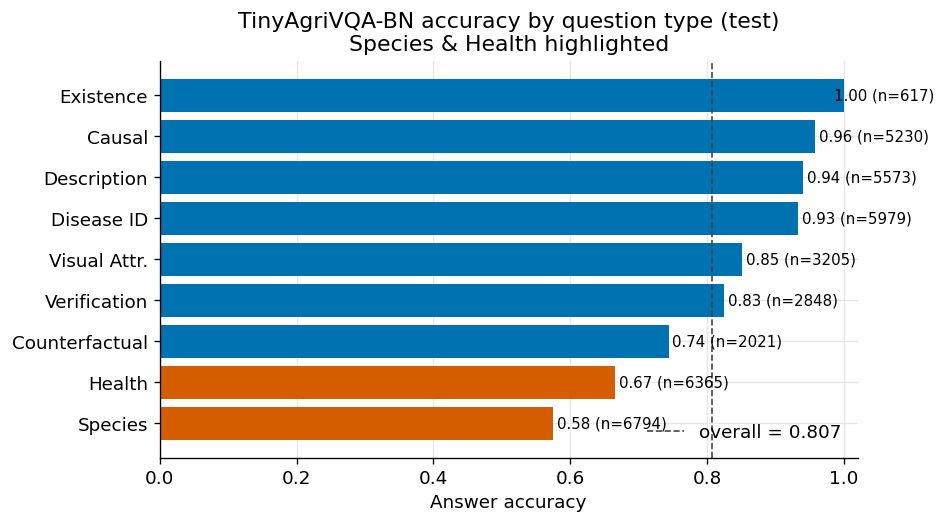

Saved: /kaggle/working/review_revision/figures/per_category_accuracy.png


In [16]:
# ============================================================
# §3.4 Figure: accuracy by question type (test)
# ============================================================
if PER_CATEGORY_AVAILABLE and tt is not None and len(tt):
    d = tt.sort_values("accuracy")
    fig, ax = plt.subplots(figsize=(8, 4.5))
    colors = [PALETTE[3] if s in ("Species", "Health") else PALETTE[0] for s in d["short"]]
    ax.barh(d["short"], d["accuracy"], color=colors)
    overall = float(test_pred["correct"].mean())
    ax.axvline(overall, color="#444", ls="--", lw=1, label=f"overall = {overall:.3f}")
    for y, (v, n) in enumerate(zip(d["accuracy"], d["n"])):
        ax.text(min(v + 0.005, 0.985), y, f"{v:.2f} (n={n})", va="center", fontsize=9)
    ax.set_xlabel("Answer accuracy")
    ax.set_xlim(0, 1.02)
    ax.set_title("TinyAgriVQA-BN accuracy by question type (test)\nSpecies & Health highlighted")
    ax.legend(loc="lower right", frameon=False)
    plt.tight_layout()
    plt.savefig(REV_FIG / "per_category_accuracy.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", REV_FIG / "per_category_accuracy.png")

### §3.5 — Interpretation guardrail for the paper

The results support a more specific explanation than “visually similar leaves” alone.

- **Species / Plant Species Identification.** This category contains both direct crop-name answers
  and binary verification-style answers. The confusion table should therefore be read at the
  **answer-family** level as well as the crop level. Errors that cross from a crop/description answer
  to `হ্যাঁ/না` (or the reverse) indicate that the model does not always use the question formulation
  strongly enough to constrain the valid answer family. Visual similarity between crops may still
  contribute, but the exported predictions by themselves do not isolate that mechanism.
- **Health / General Health Assessment.** Most errors are binary healthy/diseased swaps. This is
  consistent with a difficult visual boundary for mild symptoms, but it should be reported as an
  observed confusion pattern rather than proof of intrinsic ambiguity.

Use `reports/species_health_error_diagnostics.json` for the measured error rates, confidence, and
answer-family mismatch share. Avoid claiming that the failures are purely appearance-driven.


---
# §4 — Component ablation study  *(Reviewer #1, comment 4 — R1.4)*

> *"Provide an ablation study for individual model components and mention the contribution of gated
> fusion, masked auxiliary supervision, and multitask learning separately to justify each
> architectural design choice."*

We train four variants **under identical settings** (same seed, epochs, data subset, optimizer) so
the only thing that changes is the component under test:

| Variant | Gated fusion | Masked aux | Multitask heads | Isolates |
|--------|:---:|:---:|:---:|---|
| **Full** (ours) | ✓ | ✓ | ✓ | — |
| **− Gated fusion** (concat) | ✗ | ✓ | ✓ | value of gating |
| **− Masked aux** (unmasked) | ✓ | ✗ | ✓ | value of reliability masking |
| **− Multitask** (answer-only) | ✓ | — | ✗ | value of auxiliary tasks |

> Runs at `VARIANT_EPOCHS` epochs on `SUBSET_FRAC` of train (see §0.1) so all four fit one Kaggle
> session. Increase both for camera-ready numbers. The 12-epoch full model result from Portion 3
> (test acc ≈ 0.807, macro-F1 ≈ 0.834) is printed alongside as the reference.

In [17]:
# ============================================================
# §4.1 Build datasets shared by training-based revision experiments
# ============================================================
TRAINING_REQUESTED = RUN_ABLATIONS or RUN_LOSS_SWEEP or (RUN_BASELINES and RUN_CLIP_BASELINE)
TRAINING_READY = bool(IMAGE_DATA_OK and len(train_df) and len(val_df) and len(test_df))
ds_train = ds_val = ds_test = None

if TRAINING_REQUESTED and not TRAINING_READY:
    print("Training-based sections (§4/§5 and optional CLIP in §6) will skip because one or more images are unavailable.")
elif TRAINING_REQUESTED:
    _img_sz = RevConfig().image_size
    train_sub = subset_df(train_df, SUBSET_FRAC, VARIANT_SEED)
    print(f"Train rows used per variant: {len(train_sub)} ({len(train_sub)/len(train_df):.1%} of {len(train_df)})")
    ds_train = TinyAgriVQADataset(train_sub, tokenizer, build_image_transform(_img_sz, train=True), "train")
    ds_val   = TinyAgriVQADataset(val_df, tokenizer, build_image_transform(_img_sz, train=False), "val")
    ds_test  = TinyAgriVQADataset(test_df, tokenizer, build_image_transform(_img_sz, train=False), "test")
    print("Datasets ready -> train:", len(ds_train), "val:", len(ds_val), "test:", len(ds_test))


@torch.no_grad()
def eval_result_on_dataset(result, cfg, dataset, image_encoder=None, batch_size=None):
    if dataset is None:
        raise ValueError("Evaluation dataset is unavailable")
    model = new_model(cfg, image_encoder=image_encoder).to(DEVICE)
    if DEVICE.type == "cuda" and USE_CHANNELS_LAST:
        model = model.to(memory_format=torch.channels_last)
    load_result_state(model, result, strict=True)
    model.eval()
    bs = min(batch_size or cfg.eval_batch_size, len(dataset))
    loader = DataLoader(dataset, batch_size=max(1, bs), shuffle=False, num_workers=0,
                        pin_memory=torch.cuda.is_available())
    logits, labels = [], []
    use_amp = DEVICE.type == "cuda"
    for batch in loader:
        bd = to_device(batch, DEVICE)
        with amp_context(use_amp):
            out = model(bd["image"], bd["input_ids"], bd["attention_mask"])
        logits.append(out["answer_logits"].detach().float().cpu())
        labels.append(batch["answer_id"])
    metrics = answer_metrics(torch.cat(logits).numpy(), torch.cat(labels).numpy())
    del model, loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return metrics

Train rows used per variant: 139381 (100.0% of 139381)
Datasets ready -> train: 139381 val: 15596 test: 38632


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
# ============================================================
# §4.2 Define and run the four ablation variants
# ============================================================
def make_cfg(**over):
    c = RevConfig(epochs=VARIANT_EPOCHS)
    for k, v in over.items():
        if not hasattr(c, k):
            raise AttributeError(f"Unknown RevConfig field: {k}")
        setattr(c, k, v)
    return c

ablation_specs = [
    ("Full (ours)",            make_cfg(fusion_type="gated",  use_masked_aux=True)),
    ("- Gated fusion",         make_cfg(fusion_type="concat", use_masked_aux=True)),
    ("- Masked aux",           make_cfg(fusion_type="gated",  use_masked_aux=False)),
    ("- Multitask (ans-only)", make_cfg(fusion_type="gated", use_masked_aux=True,
                                         lambda_crop=0.0, lambda_disease=0.0, lambda_class=0.0)),
]

ablation_results = []
ablation_failures = []
if RUN_ABLATIONS and TRAINING_READY:
    for tag, cfg in ablation_specs:
        print("\n" + "#"*80 + f"\n# TRAIN VARIANT: {tag}\n" + "#"*80)
        res = None
        try:
            res = train_variant(cfg, tag, ds_train, ds_val, init_from_smoke=False)
            res["test"] = eval_result_on_dataset(res, cfg, ds_test)
            ablation_results.append((tag, cfg, res))
            print(f"  -> best val mF1={res['best_answer_macro_f1']:.4f} | "
                  f"test acc={res['test']['answer_accuracy']:.4f} "
                  f"test mF1={res['test']['answer_macro_f1']:.4f}")
        except Exception as e:
            ablation_failures.append({"variant": tag, "error": repr(e)})
            if FAIL_ON_CORE_ERROR:
                raise
            print(f"Ablation variant failed and was recorded: {tag}: {e!r}")
            traceback.print_exc(limit=2)
        finally:
            cleanup_result_state(res)
            cleanup_tag_state(tag)
    if ablation_failures:
        pd.DataFrame(ablation_failures).to_csv(REV_REP / "ablation_failures.csv", index=False)
elif RUN_ABLATIONS:
    print("§4 ablations skipped: TRAINING_READY is False.")


################################################################################
# TRAIN VARIANT: Full (ours)
################################################################################


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=25) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e8297739be0>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e829773bcb0>
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/_functional_pil.py:115: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  h = Image.fromarray(np_h, "L")
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e8297739be0>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e829773bcb0>
  self.pid = o

[Full (ours)] ep 1/6 val_acc=0.7256 val_mF1=0.4811 (best 0.4811@1) 9.8min


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=25) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e8297739be0>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e829773bcb0>
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/_functional_pil.py:115: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  h =

[Full (ours)] ep 2/6 val_acc=0.7465 val_mF1=0.5646 (best 0.5646@2) 7.8min


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=25) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e8297739be0>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e829773bcb0>
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/_functional_pil.py:115: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  h =

[- Multitask (ans-only)] ep 6/6 val_acc=0.8045 val_mF1=0.7822 (best 0.7822@6) 7.8min


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  -> best val mF1=0.7822 | test acc=0.8031 test mF1=0.7968


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


=== Ablation results (negative removal delta means the removed component helped) ===
               variant  seed  params_M  trainable_params_M  val_macro_f1  test_acc  test_macro_f1  test_weighted_f1  test_ece  wall_min  d_val_macro_f1  d_test_macro_f1  d_test_acc
           Full (ours)    42     25.49               25.49        0.7894    0.8033         0.8047            0.7900    0.0091      48.8          0.0000           0.0000      0.0000
        - Gated fusion    42     24.70               24.70        0.7920    0.8026         0.8003            0.7894    0.0124      47.4          0.0026          -0.0044     -0.0007
          - Masked aux    42     25.49               25.49        0.7940    0.8035         0.7993            0.7901    0.0088      48.0          0.0046          -0.0054      0.0002
- Multitask (ans-only)    42     25.49               25.49        0.7822    0.8031         0.7968            0.7896    0.0094      46.9         -0.0072          -0.0079     -0.0002

=== Claim

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


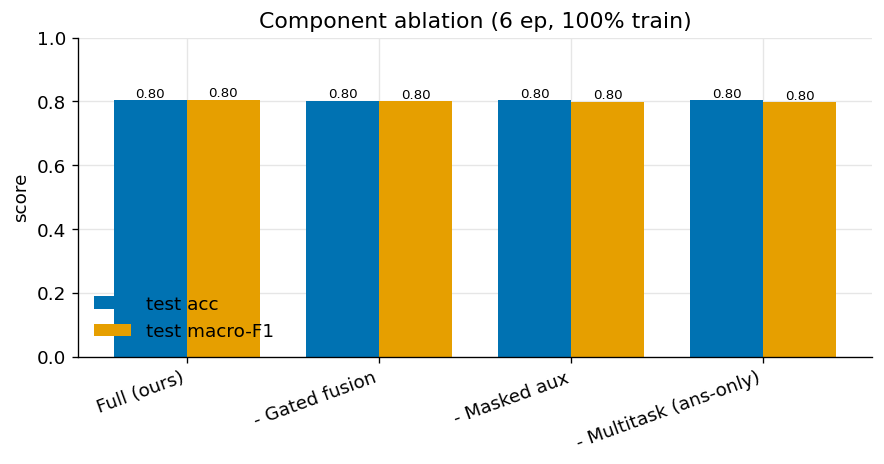

Saved: /kaggle/working/review_revision/figures/ablation.png


In [19]:
# ============================================================
# §4.3 Ablation results, figure, and claim guardrail
# ============================================================
abl = None
ABLATION_GUARDRAIL = None

if RUN_ABLATIONS and ablation_results:
    rows = []
    for tag, cfg, res in ablation_results:
        rows.append({
            "variant": tag,
            "seed": int(res.get("seed", VARIANT_SEED)),
            "params_M": round(res["params_m"], 2),
            "trainable_params_M": round(res["trainable_params_m"], 2),
            "val_macro_f1": round(res["best_answer_macro_f1"], 4),
            "test_acc": round(res["test"]["answer_accuracy"], 4),
            "test_macro_f1": round(res["test"]["answer_macro_f1"], 4),
            "test_weighted_f1": round(res["test"]["answer_weighted_f1"], 4),
            "test_ece": round(res["test"]["answer_ece"], 4),
            "wall_min": round(res["wall_min"], 1),
        })

    abl = pd.DataFrame(rows)
    full_rows = abl[abl["variant"] == "Full (ours)"]
    if len(full_rows) != 1:
        raise RuntimeError("Ablation table requires exactly one 'Full (ours)' row")

    full = full_rows.iloc[0]
    abl["d_val_macro_f1"] = (abl["val_macro_f1"] - full["val_macro_f1"]).round(4)
    abl["d_test_macro_f1"] = (abl["test_macro_f1"] - full["test_macro_f1"]).round(4)
    abl["d_test_acc"] = (abl["test_acc"] - full["test_acc"]).round(4)
    abl.to_csv(REV_REP / "ablation_results.csv", index=False)

    guard_rows = []
    for _, row in abl.iterrows():
        if row["variant"] == "Full (ours)":
            verdict = "reference"
        elif row["d_val_macro_f1"] < 0 and row["d_test_macro_f1"] < 0:
            verdict = "consistent support in this single-seed reduced-epoch run"
        elif row["d_test_macro_f1"] < 0:
            verdict = "mixed evidence: test decreases but validation does not"
        else:
            verdict = "no positive contribution established in this run"
        guard_rows.append({
            "variant": row["variant"],
            "delta_val_macro_f1_vs_full": float(row["d_val_macro_f1"]),
            "delta_test_macro_f1_vs_full": float(row["d_test_macro_f1"]),
            "delta_test_accuracy_vs_full": float(row["d_test_acc"]),
            "evidence_verdict": verdict,
            "limitations": "single seed; reduced epochs; no confidence interval",
        })

    ABLATION_GUARDRAIL = pd.DataFrame(guard_rows)
    ABLATION_GUARDRAIL.to_csv(
        REV_REP / "ablation_claim_guardrail.csv", index=False
    )

    print("=== Ablation results (negative removal delta means the removed component helped) ===")
    print(abl.to_string(index=False))
    print("\n=== Claim guardrail ===")
    print(ABLATION_GUARDRAIL.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7.5, 4))
    x = np.arange(len(abl))
    width = 0.38
    ax.bar(x-width/2, abl["test_acc"], width, label="test acc", color=PALETTE[0])
    ax.bar(x+width/2, abl["test_macro_f1"], width, label="test macro-F1", color=PALETTE[1])
    ax.set_xticks(x)
    ax.set_xticklabels(abl["variant"], rotation=20, ha="right")
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("score")
    ax.set_title(f"Component ablation ({VARIANT_EPOCHS} ep, {SUBSET_FRAC:.0%} train)")
    ax.legend(frameon=False)
    for xi, (acc, mf1) in enumerate(zip(abl["test_acc"], abl["test_macro_f1"])):
        ax.text(xi-width/2, min(acc+0.01, 0.98), f"{acc:.2f}", ha="center", fontsize=8)
        ax.text(xi+width/2, min(mf1+0.01, 0.98), f"{mf1:.2f}", ha="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(REV_FIG / "ablation.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", REV_FIG / "ablation.png")

elif RUN_ABLATIONS:
    print("No successful ablation rows were available.")
    if ablation_failures:
        pd.DataFrame(ablation_failures).to_csv(
            REV_REP / "ablation_failures.csv", index=False
        )


### §4.4 — Interpretation guardrail

Each removal is compared with the full model under the same data, optimizer, epoch budget, and seed.
The notebook writes `reports/ablation_claim_guardrail.csv` and labels the evidence as:

- **consistent in this run** when both validation and test macro-F1 decrease;
- **mixed** when validation and test move in different directions;
- **not established** when removal does not hurt the measured score.

Because this is a single-seed reduced-epoch study, the table supports measured within-run statements,
not universal superiority claims. In particular, masked auxiliary supervision should be described as
supported only when its validation and test effects are directionally stable. Camera-ready claims
should use full epochs and preferably multiple seeds.


---
# §5 — Loss-weight sensitivity  *(Reviewer #2, comment 2 — R2.2)*

The submitted auxiliary weights are `(0.12, 0.20, 0.10)`. This section tests a global scale
`α ∈ {0, 0.5, 1, 2}` using the **validation** macro-F1 only. The experiment is designed to answer two
separate questions:

1. Does auxiliary supervision help relative to `α=0`?
2. Does the short sweep establish that the submitted `α=1` is optimal?

The notebook generates a data-dependent interpretation and never assumes the answer in advance.


In [20]:
# ============================================================
# §5.1 Loss-weight sensitivity sweep and data-dependent verdict
# ============================================================
AUX_SCALES = [0.0, 0.5, 1.0, 2.0]
BASE_W = {"crop": 0.12, "disease": 0.20, "class_": 0.10}

sweep_results = []
sweep_failures = []
LOSS_SWEEP_INTERPRETATION = None

if RUN_LOSS_SWEEP and TRAINING_READY:
    for alpha in AUX_SCALES:
        cfg = RevConfig(
            epochs=SWEEP_EPOCHS,
            lambda_crop=BASE_W["crop"] * alpha,
            lambda_disease=BASE_W["disease"] * alpha,
            lambda_class=BASE_W["class_"] * alpha,
        )
        tag = f"aux_scale={alpha}"
        print(
            "\n" + "="*70 +
            f"\n{tag} (crop={cfg.lambda_crop:.3f}, "
            f"disease={cfg.lambda_disease:.3f}, class={cfg.lambda_class:.3f})"
        )

        res = None
        try:
            # Every scale starts from the same compatible smoke checkpoint and seed.
            res = train_variant(
                cfg, tag, ds_train, ds_val,
                init_from_smoke=True,
                seed=VARIANT_SEED,
            )
            sweep_results.append({
                "aux_scale": float(alpha),
                "lambda_crop": round(cfg.lambda_crop, 3),
                "lambda_disease": round(cfg.lambda_disease, 3),
                "lambda_class": round(cfg.lambda_class, 3),
                "val_macro_f1": round(res["best_answer_macro_f1"], 4),
                "best_epoch": int(res["best_epoch"]),
                "seed": int(res.get("seed", VARIANT_SEED)),
                "wall_min": round(res["wall_min"], 1),
            })
        except Exception as exc:
            sweep_failures.append({"aux_scale": alpha, "error": repr(exc)})
            pd.DataFrame(sweep_failures).to_csv(
                REV_REP / "loss_weight_sweep_failures.csv", index=False
            )
            if FAIL_ON_CORE_ERROR:
                raise
            print(f"Sweep point failed and was recorded: alpha={alpha}: {exc!r}")
            traceback.print_exc(limit=2)
        finally:
            cleanup_result_state(res)
            cleanup_tag_state(tag)

        if sweep_results:
            pd.DataFrame(sweep_results).sort_values("aux_scale").to_csv(
                REV_REP / "loss_weight_sweep_partial.csv", index=False
            )

    if len(sweep_results) != len(AUX_SCALES):
        raise RuntimeError(
            f"Loss sweep completed only {len(sweep_results)}/{len(AUX_SCALES)} points"
        )

    sweep = pd.DataFrame(sweep_results).sort_values("aux_scale").reset_index(drop=True)
    sweep.to_csv(REV_REP / "loss_weight_sweep.csv", index=False)

    best_row = sweep.loc[sweep["val_macro_f1"].idxmax()]
    submitted_rows = sweep[np.isclose(sweep["aux_scale"], 1.0)]
    zero_rows = sweep[np.isclose(sweep["aux_scale"], 0.0)]
    if len(submitted_rows) != 1 or len(zero_rows) != 1:
        raise RuntimeError("Loss sweep requires exactly one alpha=0 and one alpha=1 row")

    submitted_row = submitted_rows.iloc[0]
    zero_row = zero_rows.iloc[0]
    improvement_over_zero = float(
        submitted_row["val_macro_f1"] - zero_row["val_macro_f1"]
    )
    gap_to_best = float(best_row["val_macro_f1"] - submitted_row["val_macro_f1"])

    if np.isclose(best_row["aux_scale"], 1.0):
        exact_weight_verdict = "submitted alpha=1 is best among tested points"
    elif gap_to_best <= 0.005:
        exact_weight_verdict = (
            "submitted alpha=1 is within 0.005 macro-F1 of the best tested point"
        )
    else:
        exact_weight_verdict = (
            "submitted alpha=1 is not the best tested point; exact optimality is not established"
        )

    LOSS_SWEEP_INTERPRETATION = {
        "best_alpha": float(best_row["aux_scale"]),
        "best_val_macro_f1": float(best_row["val_macro_f1"]),
        "submitted_alpha": 1.0,
        "submitted_val_macro_f1": float(submitted_row["val_macro_f1"]),
        "answer_only_val_macro_f1": float(zero_row["val_macro_f1"]),
        "submitted_improvement_over_answer_only": round(improvement_over_zero, 6),
        "submitted_gap_to_best": round(gap_to_best, 6),
        "auxiliary_supervision_helped_at_alpha_1": bool(improvement_over_zero > 0),
        "exact_weight_verdict": exact_weight_verdict,
        "limitations": [
            "single seed",
            "reduced epoch budget",
            "coarse four-point scale grid",
        ],
    }
    with open(
        REV_REP / "loss_weight_interpretation.json",
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            LOSS_SWEEP_INTERPRETATION,
            f,
            indent=2,
            ensure_ascii=False,
            allow_nan=False,
        )

    paper_sentence = (
        "A short validation-only sensitivity analysis over auxiliary scale "
        f"alpha in {AUX_SCALES} found alpha={best_row['aux_scale']:.1f} "
        f"to have the highest macro-F1 ({best_row['val_macro_f1']:.4f}); "
        f"the submitted alpha=1.0 reached {submitted_row['val_macro_f1']:.4f}, "
        f"compared with {zero_row['val_macro_f1']:.4f} without auxiliary losses. "
        f"Thus, {exact_weight_verdict}. "
        "The result supports the role of auxiliary supervision but should not be "
        "presented as a multi-seed or full-budget optimum."
    )
    (REV_REP / "loss_weight_paper_sentence.txt").write_text(
        paper_sentence, encoding="utf-8"
    )

    print("\n=== Loss-weight sensitivity (validation answer macro-F1) ===")
    print(sweep.to_string(index=False))
    print("\nInterpretation:", json.dumps(
        LOSS_SWEEP_INTERPRETATION, indent=2, ensure_ascii=False
    ))

elif RUN_LOSS_SWEEP:
    raise RuntimeError("§5 loss sweep requested but TRAINING_READY is False")



aux_scale=0.0 (crop=0.000, disease=0.000, class=0.000)
  warm-start P2 smoke: matched=284 missing=0 unexpected=0 shape-skipped=0


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=25) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e8297739be0>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e829773bcb0>
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/_functional_pil.py:115: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  h = Image.fromarray(np_h, "L")
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e8297739be0>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e829773bcb0>
  self.pid = o

[aux_scale=0.0] ep 1/4 val_acc=0.7275 val_mF1=0.4677 (best 0.4677@1) 7.9min


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=25) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e8297739be0>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e829773bcb0>
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/_functional_pil.py:115: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  h =

[aux_scale=0.0] ep 2/4 val_acc=0.7579 val_mF1=0.6201 (best 0.6201@2) 7.7min


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=25) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e8297739be0>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e829773bcb0>
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/_functional_pil.py:115: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  h =

[aux_scale=2.0] ep 3/4 val_acc=0.7898 val_mF1=0.7395 (best 0.7395@3) 7.8min


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=25) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e8297739be0>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7e829773bcb0>
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/_functional_pil.py:115: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  h =

[aux_scale=2.0] ep 4/4 val_acc=0.7952 val_mF1=0.7655 (best 0.7655@4) 7.8min

=== Loss-weight sensitivity (validation answer macro-F1) ===
 aux_scale  lambda_crop  lambda_disease  lambda_class  val_macro_f1  best_epoch  seed  wall_min
       0.0         0.00             0.0          0.00        0.7417           4    42      31.3
       0.5         0.06             0.1          0.05        0.7590           4    42      31.5
       1.0         0.12             0.2          0.10        0.7537           4    42      31.8
       2.0         0.24             0.4          0.20        0.7655           4    42      31.2

Interpretation: {
  "best_alpha": 2.0,
  "best_val_macro_f1": 0.7655,
  "submitted_alpha": 1.0,
  "submitted_val_macro_f1": 0.7537,
  "answer_only_val_macro_f1": 0.7417,
  "submitted_improvement_over_answer_only": 0.012,
  "submitted_gap_to_best": 0.0118,
  "auxiliary_supervision_helped_at_alpha_1": true,
  "exact_weight_verdict": "submitted alpha=1 is not the best tested point;

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


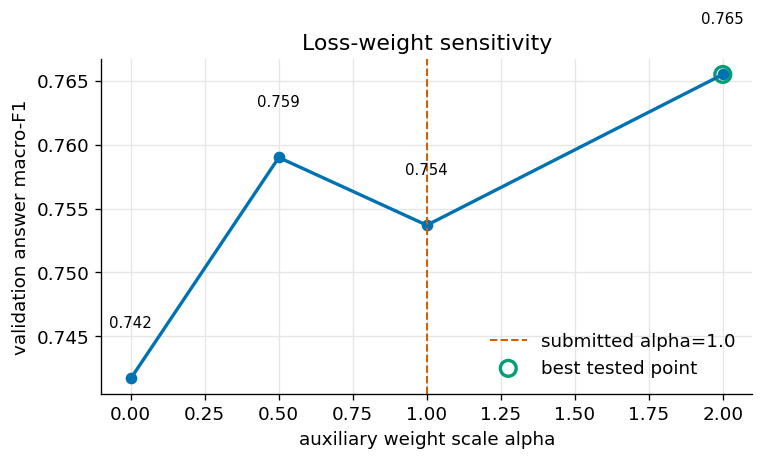

Saved: /kaggle/working/review_revision/figures/loss_weight_sweep.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
# ============================================================
# §5.2 Loss-weight figure
# ============================================================
if RUN_LOSS_SWEEP and sweep_results:
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(
        sweep["aux_scale"],
        sweep["val_macro_f1"],
        "-o",
        color=PALETTE[0],
        lw=2,
    )
    ax.axvline(
        1.0,
        color=PALETTE[3],
        ls="--",
        lw=1.2,
        label="submitted alpha=1.0",
    )
    best_idx = int(sweep["val_macro_f1"].idxmax())
    ax.scatter(
        [sweep.loc[best_idx, "aux_scale"]],
        [sweep.loc[best_idx, "val_macro_f1"]],
        s=90,
        facecolors="none",
        edgecolors=PALETTE[2],
        linewidths=2,
        label="best tested point",
    )
    for x, y in zip(sweep["aux_scale"], sweep["val_macro_f1"]):
        ax.text(x, min(y + 0.004, 0.99), f"{y:.3f}", ha="center", fontsize=9)
    ax.set_xlabel("auxiliary weight scale alpha")
    ax.set_ylabel("validation answer macro-F1")
    ax.set_title("Loss-weight sensitivity")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(REV_FIG / "loss_weight_sweep.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", REV_FIG / "loss_weight_sweep.png")


### §5.3 — Paper-use guardrail

The design rationale remains:

- the answer objective is primary (`λ_answer=1`);
- disease receives the largest auxiliary coefficient because it is the most directly diagnostic;
- crop and class receive smaller coefficients.

The empirical conclusion must come from
`reports/loss_weight_interpretation.json` and
`reports/loss_weight_paper_sentence.txt`. Do **not** write that `α=1` is near-optimal unless the
generated verdict supports that claim. A short, single-seed sweep can demonstrate that auxiliary
supervision helps without establishing the exact optimal coefficients.


---
# §6 — Baseline comparison  *(Reviewer #1, comment 3 — R1.3)*

This section produces:

1. **Majority-per-question-type**, a deterministic non-neural lower bound.
2. **TinyAgriVQA-BN**, reported from Portion 3 or from the full ablation row.
3. **Optional frozen CLIP ViT-B/32 visual-backbone comparator**, when local Hugging Face weights are
   attached.

The CLIP row is a pretrained **visual-backbone comparator**, not a full end-to-end CLIP/ViLT/BLIP
VQA system. The notebook records that distinction explicitly. When no local CLIP directory is
available, the row is marked skipped and the notebook continues; the reviewer-readiness report marks
R1.3 as partial rather than falsely complete.


In [22]:
# ============================================================
# §6.1 Majority-per-question-type baseline (no training)
# ============================================================
baseline_rows = []
if RUN_BASELINES and "question_type" in train_df.columns and "question_type" in test_df.columns:
    maj = (train_df.groupby("question_type")["p2_answer_id"]
                   .agg(lambda s: s.value_counts().index[0]).to_dict())
    global_maj = int(train_df["p2_answer_id"].value_counts().index[0])
    tdf = test_df.copy()
    tdf["pred"] = tdf["question_type"].map(maj).fillna(global_maj).astype(int)
    acc = float((tdf["pred"] == tdf["p2_answer_id"]).mean())
    mf1 = float(f1_score(tdf["p2_answer_id"], tdf["pred"], average="macro", zero_division=0))
    baseline_rows.append({"model":"Majority-per-type", "backbone":"none", "params_M":0.0,
                          "test_acc":round(acc,4), "test_macro_f1":round(mf1,4), "status":"completed"})
    print("Majority-per-type -> test acc:", round(acc,4), "macro-F1:", round(mf1,4))
elif RUN_BASELINES:
    print("Majority-per-type skipped: question_type is absent from train/test tables.")

Majority-per-type -> test acc: 0.4078 macro-F1: 0.0393


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
# ============================================================
# §6.2 Optional frozen CLIP visual-backbone comparator
# ============================================================
CLIP_OK = False
CLIP_STATUS = "not requested"
CLIP_RESOLVED_SOURCE = None


def _path_is_under(path, parent):
    try:
        Path(path).resolve().relative_to(Path(parent).resolve())
        return True
    except Exception:
        return False


def _looks_like_local_clip_dir(path):
    path = Path(path)
    config_path = path / "config.json"
    if not config_path.is_file():
        return False
    try:
        cfg = json.loads(config_path.read_text(encoding="utf-8"))
    except Exception:
        return False

    model_type = str(cfg.get("model_type", "")).lower()
    architectures = [str(x).lower() for x in cfg.get("architectures", [])]
    clip_config = (
        model_type in {"clip", "clip_vision_model"}
        or any("clipvisionmodel" in x or x == "clipmodel" for x in architectures)
    )
    if not clip_config:
        return False

    weight_candidates = [
        path / "model.safetensors",
        path / "pytorch_model.bin",
        path / "model.safetensors.index.json",
        path / "pytorch_model.bin.index.json",
    ]
    return any(p.is_file() for p in weight_candidates)


def discover_local_clip_dir():
    explicit = CLIP_MODEL_SOURCE
    if explicit:
        explicit_path = Path(explicit)
        if explicit_path.exists():
            if not _looks_like_local_clip_dir(explicit_path):
                raise ValueError(
                    "CLIP_MODEL_SOURCE exists but is not a valid "
                    f"Hugging Face CLIP directory: {explicit_path}"
                )
            return str(explicit_path), "explicit local path"
        if ALLOW_NETWORK_MODEL_DOWNLOAD:
            return explicit, "explicit repository ID"
        return None, (
            "CLIP_MODEL_SOURCE is not a local directory and "
            "network download is disabled"
        )

    input_root = Path("/kaggle/input")
    if input_root.exists():
        try:
            roots = [
                path for path in input_root.iterdir()
                if path.is_dir()
            ]
        except Exception:
            roots = []

        # Avoid traversing the full image dataset. Auto-discovery checks
        # model-like Kaggle inputs; users can always provide an explicit path.
        model_tokens = {
            "clip", "huggingface", "hf", "transformer", "model"
        }
        roots = [
            root for root in roots
            if any(
                token in root.name.lower()
                for token in model_tokens
            )
            and not _path_is_under(root, PROJECT_DIR)
        ]

        checked = 0
        for root in roots:
            direct = root / "config.json"
            if direct.is_file() and _looks_like_local_clip_dir(root):
                return str(root), "auto-discovered local model"

            for config_path in root.rglob("config.json"):
                checked += 1
                if checked > 300:
                    break
                candidate = config_path.parent
                if _looks_like_local_clip_dir(candidate):
                    return str(candidate), "auto-discovered local model"
            if checked > 300:
                break

    if ALLOW_NETWORK_MODEL_DOWNLOAD:
        return "openai/clip-vit-base-patch32", "default repository ID"
    return None, (
        "no local CLIP model found and network download is disabled"
    )


if RUN_BASELINES and RUN_CLIP_BASELINE:
    CLIP_RESOLVED_SOURCE, clip_source_reason = discover_local_clip_dir()

    if not TRAINING_READY:
        CLIP_STATUS = "skipped: source images unavailable"
    elif CLIP_RESOLVED_SOURCE is None:
        CLIP_STATUS = f"skipped: {clip_source_reason}"
    else:
        res_clip = None
        clip_encoder = test_encoder = None
        ds_tr_clip = ds_va_clip = ds_te_clip = None
        try:
            from transformers import CLIPVisionModel

            class CLIPImageEncoder(nn.Module):
                def __init__(self, source, freeze=True):
                    super().__init__()
                    self.freeze = bool(freeze)
                    self.vision = CLIPVisionModel.from_pretrained(
                        source,
                        local_files_only=CLIP_LOCAL_FILES_ONLY,
                    )
                    self.out_dim = int(self.vision.config.hidden_size)
                    if self.freeze:
                        for parameter in self.vision.parameters():
                            parameter.requires_grad = False
                        self.vision.eval()

                def train(self, mode=True):
                    super().train(mode)
                    if self.freeze:
                        self.vision.eval()
                    return self

                def forward(self, images):
                    return self.vision(pixel_values=images).pooler_output

            def build_clip_transform(size=224):
                if TORCHVISION_OK:
                    return transforms.Compose([
                        transforms.Resize((size, size)),
                        transforms.ToTensor(),
                        transforms.Normalize(
                            [0.4815, 0.4578, 0.4082],
                            [0.2686, 0.2613, 0.2758],
                        ),
                    ])
                mean = np.asarray(
                    [0.4815, 0.4578, 0.4082], np.float32
                ).reshape(3, 1, 1)
                std = np.asarray(
                    [0.2686, 0.2613, 0.2758], np.float32
                ).reshape(3, 1, 1)

                def _transform(image):
                    arr = np.asarray(
                        image.resize((size, size)), np.float32
                    ).transpose(2, 0, 1) / 255.0
                    return torch.from_numpy((arr - mean) / std)

                return _transform

            # Fail before dataset construction if the local model is incomplete.
            probe = CLIPImageEncoder(CLIP_RESOLVED_SOURCE, freeze=True)
            del probe
            gc.collect()

            clip_transform = build_clip_transform(RevConfig().image_size)
            ds_tr_clip = TinyAgriVQADataset(
                subset_df(train_df, SUBSET_FRAC, VARIANT_SEED),
                tokenizer,
                clip_transform,
                "train_clip",
            )
            ds_va_clip = TinyAgriVQADataset(
                val_df, tokenizer, clip_transform, "val_clip"
            )
            ds_te_clip = TinyAgriVQADataset(
                test_df, tokenizer, clip_transform, "test_clip"
            )

            cfg_clip = RevConfig(
                epochs=VARIANT_EPOCHS,
                image_encoder_lr=0.0,
            )
            clip_encoder = CLIPImageEncoder(
                CLIP_RESOLVED_SOURCE, freeze=True
            )
            res_clip = train_variant(
                cfg_clip,
                "CLIP-ViT-32_backbone",
                ds_tr_clip,
                ds_va_clip,
                init_from_smoke=False,
                image_encoder=clip_encoder,
                seed=VARIANT_SEED,
            )

            test_encoder = CLIPImageEncoder(
                CLIP_RESOLVED_SOURCE, freeze=True
            )
            clip_metrics = eval_result_on_dataset(
                res_clip,
                cfg_clip,
                ds_te_clip,
                image_encoder=test_encoder,
                batch_size=128,
            )
            baseline_rows.append({
                "model": "CLIP-ViT/32 frozen visual tower + BN text",
                "backbone": "CLIP ViT-B/32",
                "params_M": round(res_clip["params_m"], 2),
                "test_acc": round(clip_metrics["answer_accuracy"], 4),
                "test_macro_f1": round(
                    clip_metrics["answer_macro_f1"], 4
                ),
                "status": "completed",
                "comparison_scope": (
                    "pretrained visual-backbone comparator; not full CLIP VQA"
                ),
            })
            CLIP_OK = True
            CLIP_STATUS = "completed"
            print(
                "CLIP comparator -> test acc:",
                round(clip_metrics["answer_accuracy"], 4),
                "macro-F1:",
                round(clip_metrics["answer_macro_f1"], 4),
            )

        except Exception as exc:
            CLIP_STATUS = f"failed: {exc!r}"
            if FAIL_ON_OPTIONAL_RUNTIME_ERROR or REQUIRE_CLIP_BASELINE:
                raise
            print("Optional CLIP comparator failed safely:", repr(exc))
            traceback.print_exc(limit=2)
        finally:
            cleanup_result_state(res_clip)
            cleanup_tag_state("CLIP-ViT-32_backbone")
            # Drop references explicitly. Assigning through locals() is not guaranteed
            # to update fast local variables in Python functions/cells.
            clip_encoder = None
            test_encoder = None
            ds_tr_clip = None
            ds_va_clip = None
            ds_te_clip = None
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    if CLIP_STATUS != "completed":
        baseline_rows.append({
            "model": "CLIP-ViT/32 frozen visual tower + BN text",
            "backbone": "CLIP ViT-B/32",
            "params_M": np.nan,
            "test_acc": np.nan,
            "test_macro_f1": np.nan,
            "status": CLIP_STATUS,
            "comparison_scope": (
                "pretrained visual-backbone comparator; not full CLIP VQA"
            ),
        })
        print("CLIP comparator status:", CLIP_STATUS)

elif RUN_BASELINES:
    CLIP_STATUS = "not requested"

with open(REV_REP / "clip_baseline_status.json", "w", encoding="utf-8") as f:
    json.dump({
        "requested": bool(RUN_BASELINES and RUN_CLIP_BASELINE),
        "required": bool(REQUIRE_CLIP_BASELINE),
        "status": CLIP_STATUS,
        "resolved_source": CLIP_RESOLVED_SOURCE,
        "local_files_only": bool(CLIP_LOCAL_FILES_ONLY),
        "scope": "frozen visual-backbone comparator; not full CLIP VQA",
    }, f, indent=2, ensure_ascii=False, allow_nan=False)


CLIP comparator status: skipped: no local CLIP model found and network download is disabled


In [24]:
# ============================================================
# §6.3 Assemble the provenance-aware baseline comparison table
# ============================================================
bl = None
if RUN_BASELINES:
    # The official Portion-3 result remains the manuscript reference. It is
    # not silently replaced by the reduced-epoch ablation rerun.
    main_params = np.nan
    if ablation_results:
        full_match = [
            row for row in ablation_results
            if row[0] == "Full (ours)"
        ]
        if len(full_match) == 1:
            main_params = round(full_match[0][2]["params_m"], 2)

    baseline_rows.append({
        "model": "TinyAgriVQA-BN (Portion-3 main)",
        "backbone": "ResNet-34 (random initialization)",
        "params_M": main_params,
        "test_acc": 0.8072,
        "test_macro_f1": 0.8341,
        "status": "reference",
        "comparison_scope": (
            "existing Portion-3 full training result exported by the source notebook"
        ),
    })

    if ablation_results:
        full_match = [
            row for row in ablation_results
            if row[0] == "Full (ours)"
        ]
        if len(full_match) == 1:
            _, _, full_res = full_match[0]
            baseline_rows.append({
                "model": "TinyAgriVQA-BN (matched-budget rerun)",
                "backbone": "ResNet-34 (random initialization)",
                "params_M": round(full_res["params_m"], 2),
                "test_acc": round(
                    full_res["test"]["answer_accuracy"], 4
                ),
                "test_macro_f1": round(
                    full_res["test"]["answer_macro_f1"], 4
                ),
                "status": "completed",
                "comparison_scope": (
                    f"{VARIANT_EPOCHS} epochs, {SUBSET_FRAC:.0%} train, "
                    f"seed={VARIANT_SEED}; matched to the revision-variant budget"
                ),
            })

    bl = pd.DataFrame(baseline_rows)
    preferred_columns = [
        "model",
        "backbone",
        "params_M",
        "test_acc",
        "test_macro_f1",
        "status",
        "comparison_scope",
    ]
    for column in preferred_columns:
        if column not in bl.columns:
            bl[column] = np.nan
    bl = bl[preferred_columns]
    bl.to_csv(
        REV_REP / "baseline_comparison.csv",
        index=False,
    )

    print("=== Baseline comparison ===")
    print(bl.to_string(index=False))
    print("\nCLIP comparator status:", CLIP_STATUS)
    print(
        "Guardrail: compare the optional CLIP row with the matched-budget rerun; "
        "the Portion-3 row has different training provenance."
    )


=== Baseline comparison ===
                                    model                          backbone  params_M  test_acc  test_macro_f1                                                              status                                                        comparison_scope
                        Majority-per-type                              none      0.00    0.4078         0.0393                                                           completed                                                                     NaN
CLIP-ViT/32 frozen visual tower + BN text                     CLIP ViT-B/32       NaN       NaN            NaN skipped: no local CLIP model found and network download is disabled                pretrained visual-backbone comparator; not full CLIP VQA
          TinyAgriVQA-BN (Portion-3 main) ResNet-34 (random initialization)     25.49    0.8072         0.8341                                                           reference existing Portion-3 full training result 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
# ============================================================
# §6.4 (Optional, separate session) ViLT / BLIP VQA stubs — English-centric, heavy
# ============================================================
VILT_BLIP_STUB = r"""
# Run these in a DEDICATED Kaggle session (internet ON). They are English-tokenizer models,
# so for Bengali you must either (a) translate questions to English for the baseline, or
# (b) evaluate zero-shot on the English PlantVillageVQA questions. Report both honestly.
#
# from transformers import ViltProcessor, ViltForQuestionAnswering
# proc = ViltProcessor.from_pretrained('dandelin/vilt-b32-finetuned-vqa')
# model = ViltForQuestionAnswering.from_pretrained('dandelin/vilt-b32-finetuned-vqa')
#
# from transformers import BlipProcessor, BlipForQuestionAnswering
# bproc = BlipProcessor.from_pretrained('Salesforce/blip-vqa-base')
# bmodel = BlipForQuestionAnswering.from_pretrained('Salesforce/blip-vqa-base')
#
# Fine-tune the classifier head on the (English) train split for VARIANT_EPOCHS and evaluate.
"""
print("ViLT/BLIP stub available in variable VILT_BLIP_STUB (kept out of the main run for time).")


ViLT/BLIP stub available in variable VILT_BLIP_STUB (kept out of the main run for time).


---
# §7 — In-the-wild / real-world validation  *(Reviewer #1, comment 2 — R1.2)*

> *"Validate the proposed model on real-world datasets ... field-acquired crop images or publicly
> available in-the-wild plant disease datasets to demonstrate practical applicability beyond the
> controlled PlantVillage environment."*

We run a **zero-shot cross-domain** test on an external field dataset (default: **PlantDoc**, which
has cluttered, real-field backgrounds). Because label spaces differ across datasets, we evaluate the
two heads that transfer cleanly:

- **Species transfer** — the model's `crop_head` prediction vs. the crop parsed from the external
  folder name.
- **Health transfer** — healthy vs. diseased, derived from the external class name vs. the model's
  disease/class head.

> **Attach a dataset first.** On Kaggle, add an in-the-wild dataset (search "PlantDoc") as an input.
> Set `EXTERNAL_DIR` below or let auto-discovery find an `ImageFolder`-style tree under
> `/kaggle/input`. If none is found the section prints instructions and skips — it never hard-fails.

In [26]:
# ============================================================
# §7.1 Locate an external ImageFolder-style field dataset
# ============================================================
EXTERNAL_DIR = EXTERNAL_DIR_OVERRIDE


def looks_like_imagefolder(directory, min_classes=3, min_images=20):
    directory = Path(directory)
    if not directory.exists() or not directory.is_dir():
        return False
    try:
        class_dirs = [p for p in directory.iterdir() if p.is_dir()]
    except Exception:
        return False
    if len(class_dirs) < min_classes:
        return False

    image_count = 0
    for class_dir in class_dirs:
        try:
            image_count += sum(
                1
                for path in class_dir.iterdir()
                if path.is_file() and path.suffix.lower() in IMAGE_EXTS
            )
        except Exception:
            continue
        if image_count >= min_images:
            return True
    return image_count >= min_images


def _is_under(path, parent):
    try:
        Path(path).resolve().relative_to(Path(parent).resolve())
        return True
    except Exception:
        return False


def discover_external():
    if EXTERNAL_DIR:
        if looks_like_imagefolder(EXTERNAL_DIR):
            return Path(EXTERNAL_DIR)
        raise ValueError(
            "EXTERNAL_DIR_OVERRIDE was set but is not an ImageFolder-style dataset: "
            f"{EXTERNAL_DIR}"
        )

    input_root = Path("/kaggle/input")
    if not input_root.exists():
        return None

    name_tokens = [
        "plantdoc",
        "field",
        "in-the-wild",
        "inthewild",
        "wild",
    ]
    try:
        top_level = [
            path for path in input_root.iterdir()
            if path.is_dir()
        ]
    except Exception:
        top_level = []

    candidates = []
    for root in top_level:
        if _is_under(root, PROJECT_DIR) or _is_under(
            root, INPUT_NOTEBOOK_ROOT
        ):
            continue

        # Safe auto-discovery is intentionally name-gated. Users can set an
        # explicit path for datasets with an unrelated Kaggle slug.
        if not any(
            token in str(root).lower()
            for token in name_tokens
        ):
            continue

        if looks_like_imagefolder(root):
            candidates.append(root)

        checked = 0
        for dirpath, dirnames, _ in os.walk(root):
            checked += 1
            if checked > 500:
                break
            directory = Path(dirpath)
            if directory == root:
                continue
            if looks_like_imagefolder(directory):
                candidates.append(directory)

    candidates = list({
        _path_key(candidate): candidate
        for candidate in candidates
    }.values())
    candidates.sort(
        key=lambda path: (
            0 if "test" in path.name.lower() else 1,
            len(str(path)),
        )
    )
    return candidates[0] if candidates else None


EXT = None
EXTERNAL_DISCOVERY_STATUS = "not requested"
if RUN_INTHEWILD:
    try:
        EXT = discover_external()
        if EXT is None:
            EXTERNAL_DISCOVERY_STATUS = "skipped: no external field dataset found"
            print(
                "No separate external field dataset found.\n"
                "  -> Attach PlantDoc or another real-field ImageFolder input.\n"
                "  -> Optionally set TINYAGRIVQA_EXTERNAL_DIR.\n"
                "  -> Expected layout: <root>/<ClassName>/<image>.jpg\n"
                "  -> The Portion 1–3 controlled image tree is excluded."
            )
        else:
            EXTERNAL_DISCOVERY_STATUS = "found"
            classes = sorted(
                [path.name for path in EXT.iterdir() if path.is_dir()]
            )
            print("External dataset:", EXT)
            print(
                "Classes:",
                len(classes),
                classes[:12],
                "..." if len(classes) > 12 else "",
            )
    except Exception as exc:
        EXTERNAL_DISCOVERY_STATUS = f"failed: {exc!r}"
        if FAIL_ON_OPTIONAL_RUNTIME_ERROR or REQUIRE_EXTERNAL_EVAL:
            raise
        print("External dataset discovery failed safely:", repr(exc))


No separate external field dataset found.
  -> Attach PlantDoc or another real-field ImageFolder input.
  -> Optionally set TINYAGRIVQA_EXTERNAL_DIR.
  -> Expected layout: <root>/<ClassName>/<image>.jpg
  -> The Portion 1–3 controlled image tree is excluded.


In [27]:
# ============================================================
# §7.2 Normalize external class names into the shared crop/health space
# ============================================================
def normalize_label_text(value):
    text = "" if value is None else str(value).lower()
    text = text.replace("&", " and ")
    text = re.sub(r"[_\-/]+", " ", text)
    text = re.sub(r"[^0-9a-z\u0980-\u09ff]+", " ", text)
    return " ".join(text.split())


id_to_crop = {
    int(v): normalize_label_text(k)
    for k, v in label_mapping["crop_to_id"].items()
}
id_to_disease = {
    int(v): normalize_label_text(k)
    for k, v in label_mapping["disease_to_id"].items()
}
id_to_class = {
    int(v): normalize_label_text(k)
    for k, v in label_mapping["class_to_id"].items()
}

# Longest names are checked first to avoid a short label winning inside
# a more specific one.
CROP_CANONICAL_NAMES = sorted(
    set(id_to_crop.values()),
    key=lambda value: (-len(value), value),
)
HEALTHY_MARKERS = {
    "healthy", "health", "normal", "সুস্থ", "রোগমুক্ত",
}


def label_mentions_healthy(value):
    normalized = normalize_label_text(value)
    return any(marker in normalized for marker in HEALTHY_MARKERS)


def parse_external(class_name):
    """
    Map an ImageFolder class name to:
      (canonical crop label, crop matched to our vocabulary, is healthy)

    Unmatched crop names are retained as '<unmapped>' and excluded from
    species accuracy rather than being guessed from the first token.
    """
    normalized = normalize_label_text(class_name)
    crop = next(
        (
            candidate
            for candidate in CROP_CANONICAL_NAMES
            if candidate and candidate in normalized
        ),
        "<unmapped>",
    )
    is_healthy = label_mentions_healthy(normalized)
    return crop, crop != "<unmapped>", is_healthy


def crop_of_pred(crop_logits_row):
    return id_to_crop.get(
        int(np.argmax(crop_logits_row)), "<unmapped>"
    )


if RUN_INTHEWILD and EXT is not None:
    debug_rows = []
    for class_dir in sorted(
        [path for path in EXT.iterdir() if path.is_dir()]
    )[:20]:
        crop, matched, healthy = parse_external(class_dir.name)
        debug_rows.append({
            "external_class": class_dir.name,
            "normalized_class": normalize_label_text(class_dir.name),
            "mapped_crop": crop,
            "crop_in_vocab": matched,
            "healthy": healthy,
        })
    debug_map = pd.DataFrame(debug_rows)
    debug_map.to_csv(
        REV_REP / "external_label_mapping_preview.csv",
        index=False,
    )
    print("External label-map preview:")
    print(debug_map.to_string(index=False))


In [28]:
# ============================================================
# §7.3 Batched zero-shot auxiliary-head transfer evaluation
# ============================================================
class ExternalImageDataset(Dataset):
    def __init__(self, ext_dir, transform, max_per_class=200):
        self.transform = transform
        self.rows = []
        class_dirs = sorted(
            [path for path in Path(ext_dir).iterdir() if path.is_dir()]
        )
        for class_dir in class_dirs:
            crop_gold, crop_in_vocab, health_gold = parse_external(
                class_dir.name
            )
            files = sorted(
                [
                    path
                    for path in class_dir.iterdir()
                    if path.is_file() and path.suffix.lower() in IMAGE_EXTS
                ]
            )
            for file_path in files[:max_per_class]:
                self.rows.append({
                    "path": str(file_path),
                    "class": class_dir.name,
                    "crop_gold": crop_gold,
                    "crop_in_vocab": bool(crop_in_vocab),
                    "health_gold": bool(health_gold),
                })

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        try:
            with Image.open(row["path"]) as image_file:
                image = image_file.convert("RGB")
        except Exception as exc:
            if not ALLOW_CORRUPT_IMAGE_FALLBACK:
                raise RuntimeError(
                    f"Could not read external image {row['path']}: {exc!r}"
                ) from exc
            image = Image.new("RGB", (224, 224), (0, 0, 0))

        return {
            "image": self.transform(image).float(),
            "class": row["class"],
            "crop_gold": row["crop_gold"],
            "crop_in_vocab": row["crop_in_vocab"],
            "health_gold": row["health_gold"],
        }


def run_in_the_wild(ext_dir, max_per_class=200):
    if not AP["P3F_CKPT"].is_file():
        raise FileNotFoundError(
            f"P3 checkpoint required for external inference: {AP['P3F_CKPT']}"
        )

    model, _ = load_p3_best_model()
    image_size = RevConfig().image_size
    dataset = ExternalImageDataset(
        ext_dir,
        build_image_transform(image_size, train=False),
        max_per_class,
    )
    if len(dataset) == 0:
        raise ValueError(f"No external images found under {ext_dir}")

    loader = DataLoader(
        dataset,
        batch_size=min(128, len(dataset)),
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    # Separate prompts keep the question context aligned with the head being
    # inspected. These results are auxiliary-head transfer metrics, not
    # open-ended answer accuracy.
    species_question = "ছবির পাতাটি কোন ফসল বা উদ্ভিদের?"
    health_question = "এই পাতাটি কি সুস্থ নাকি রোগাক্রান্ত?"
    species_ids_np, species_attn_np = tokenizer.encode(species_question)
    health_ids_np, health_attn_np = tokenizer.encode(health_question)

    species_ids_one = torch.tensor(
        species_ids_np, dtype=torch.long, device=DEVICE
    ).unsqueeze(0)
    species_attn_one = torch.tensor(
        species_attn_np, dtype=torch.long, device=DEVICE
    ).unsqueeze(0)
    health_ids_one = torch.tensor(
        health_ids_np, dtype=torch.long, device=DEVICE
    ).unsqueeze(0)
    health_attn_one = torch.tensor(
        health_attn_np, dtype=torch.long, device=DEVICE
    ).unsqueeze(0)

    rows = []
    use_amp = DEVICE.type == "cuda"
    with torch.no_grad():
        for batch in loader:
            images = batch["image"]
            if DEVICE.type == "cuda" and USE_CHANNELS_LAST:
                images = images.to(
                    DEVICE,
                    non_blocking=True,
                    memory_format=torch.channels_last,
                )
            else:
                images = images.to(DEVICE, non_blocking=True)

            batch_size = images.shape[0]
            species_ids = species_ids_one.expand(batch_size, -1)
            species_attn = species_attn_one.expand(batch_size, -1)
            health_ids = health_ids_one.expand(batch_size, -1)
            health_attn = health_attn_one.expand(batch_size, -1)

            with amp_context(use_amp):
                species_out = model(
                    images, species_ids, species_attn
                )
                health_out = model(
                    images, health_ids, health_attn
                )

            crop_ids = (
                species_out["crop_logits"].argmax(-1).detach().cpu().tolist()
            )
            disease_ids = (
                health_out["disease_logits"].argmax(-1).detach().cpu().tolist()
            )
            class_ids = (
                health_out["class_logits"].argmax(-1).detach().cpu().tolist()
            )

            for i in range(batch_size):
                crop_pred = id_to_crop.get(
                    int(crop_ids[i]), "<unmapped>"
                )
                disease_pred = id_to_disease.get(
                    int(disease_ids[i]), ""
                )
                class_pred = id_to_class.get(
                    int(class_ids[i]), ""
                )
                health_pred = (
                    label_mentions_healthy(disease_pred)
                    or label_mentions_healthy(class_pred)
                )
                crop_gold = batch["crop_gold"][i]
                health_gold = bool(batch["health_gold"][i])
                rows.append({
                    "class": batch["class"][i],
                    "crop_gold": crop_gold,
                    "crop_in_vocab": bool(batch["crop_in_vocab"][i]),
                    "crop_pred": crop_pred,
                    "crop_correct": int(crop_pred == crop_gold),
                    "health_gold_healthy": int(health_gold),
                    "disease_head_label": disease_pred,
                    "class_head_label": class_pred,
                    "health_pred_healthy": int(health_pred),
                    "health_correct": int(health_gold == health_pred),
                })

    del model, loader, dataset
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return pd.DataFrame(rows)


itw = None
INTHEWILD_STATUS = "not requested"

if RUN_INTHEWILD and EXT is not None:
    try:
        itw = run_in_the_wild(
            EXT,
            max_per_class=MAX_EXTERNAL_PER_CLASS,
        )
        itw.to_csv(
            REV_REP / "in_the_wild_predictions.csv", index=False
        )

        species_rows = itw[itw["crop_in_vocab"] == True]
        species_acc = (
            float(species_rows["crop_correct"].mean())
            if len(species_rows) else None
        )
        health_acc = (
            float(itw["health_correct"].mean()) if len(itw) else None
        )
        mapping_coverage = (
            float(itw["crop_in_vocab"].mean()) if len(itw) else None
        )
        summary_itw = {
            "status": "completed",
            "evaluation_scope": (
                "zero-shot auxiliary-head transfer; not open-ended VQA accuracy"
            ),
            "external_dir": str(EXT),
            "n_images": int(len(itw)),
            "n_species_evaluable": int(len(species_rows)),
            "species_mapping_coverage": (
                None if mapping_coverage is None
                else round(mapping_coverage, 4)
            ),
            "species_transfer_acc": (
                None if species_acc is None else round(species_acc, 4)
            ),
            "health_transfer_acc": (
                None if health_acc is None else round(health_acc, 4)
            ),
        }
        with open(
            REV_REP / "in_the_wild_summary.json",
            "w",
            encoding="utf-8",
        ) as f:
            json.dump(
                summary_itw,
                f,
                indent=2,
                ensure_ascii=False,
                allow_nan=False,
            )
        INTHEWILD_STATUS = "completed"
        print("=== In-the-wild auxiliary-head transfer ===")
        print(json.dumps(summary_itw, indent=2, ensure_ascii=False))

    except Exception as exc:
        INTHEWILD_STATUS = f"failed: {exc!r}"
        if FAIL_ON_OPTIONAL_RUNTIME_ERROR or REQUIRE_EXTERNAL_EVAL:
            raise
        print("Optional external evaluation failed safely:", repr(exc))
        traceback.print_exc(limit=2)

elif RUN_INTHEWILD:
    INTHEWILD_STATUS = EXTERNAL_DISCOVERY_STATUS

with open(
    REV_REP / "in_the_wild_status.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump({
        "requested": bool(RUN_INTHEWILD),
        "required": bool(REQUIRE_EXTERNAL_EVAL),
        "status": INTHEWILD_STATUS,
        "external_dir": None if EXT is None else str(EXT),
        "scope": (
            "zero-shot auxiliary-head transfer; "
            "not open-ended VQA accuracy"
        ),
    }, f, indent=2, ensure_ascii=False, allow_nan=False)


### §7.4 — Interpretation guardrail

When an external field dataset is attached, this section measures **zero-shot auxiliary-head
transfer** under domain shift. Species transfer uses the crop head and health transfer derives a
binary healthy/diseased decision from the disease and class heads. These are not open-ended Bengali
VQA accuracy metrics and should not be reported as such.

Report the external dataset name, number of images, species label-mapping coverage,
`n_species_evaluable`, species transfer accuracy, and health transfer accuracy. A performance drop
relative to the controlled PlantVillage test set quantifies the field-domain gap; it does not by
itself establish deployment readiness. When no external dataset is attached, the notebook records a
clear pending status rather than fabricating a result.


---
# §8 — Dataset linguistic diversity & vocabulary analysis  *(R1.5 and R2.1)*

> **R1.5 (#1):** *"Evaluate the linguistic diversity of the generated dataset and discuss the
> limitations of template-based Bengali question generation, and assess how well the generated
> questions represent natural user queries."*
>
> **R2.1 (#2):** *"A vocabulary size of 132 tokens is quite small ... clarify this in Section 3.2,
> as a vocabulary this limited makes it tough for the model to handle real-world open-ended Bengali
> text."*

Both comments are about the **same underlying fact**: the questions are produced by a small set of
deterministic templates, which yields a small closed vocabulary. This section **quantifies** that so
the paper can state it precisely (no GPU needed).

In [29]:
# ============================================================
# §8.1 Assemble all questions across splits
# ============================================================
def all_questions():
    frames = [d for d in [train_df, val_df, test_df] if d is not None and len(d)]
    if not frames:
        return pd.DataFrame(columns=["question_type", "bangla_question"])
    chunks = []
    for f in frames:
        qtype = f["question_type"] if "question_type" in f.columns else pd.Series(["Unknown"] * len(f))
        chunks.append(pd.DataFrame({
            "question_type": qtype.fillna("Unknown").astype(str).values,
            "bangla_question": f["bangla_question"].fillna("").astype(str).values,
        }))
    return pd.concat(chunks, ignore_index=True)

QA = all_questions() if RUN_DIVERSITY else pd.DataFrame(columns=["question_type", "bangla_question"])
DIVERSITY_AVAILABLE = bool(RUN_DIVERSITY and len(QA))
if DIVERSITY_AVAILABLE:
    print("Total question instances:", len(QA))
    print("Unique question strings:", QA["bangla_question"].nunique(),
          f"({QA['bangla_question'].nunique()/len(QA):.4%} of instances)")
elif RUN_DIVERSITY:
    print("§8 diversity analysis skipped: no questions were loaded.")

Total question instances: 193609
Unique question strings: 46 (0.0238% of instances)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
# ============================================================
# §8.2 Diversity metrics: TTR, distinct-n, lengths, templates/type, entropy
# ============================================================
def tokens_of(s):
    return tokenizer.tokenize(s)

def distinct_n(list_of_token_lists, n):
    grams, total = set(), 0
    for toks in list_of_token_lists:
        for i in range(len(toks)-n+1):
            grams.add(tuple(toks[i:i+n]))
            total += 1
    return (len(grams)/total) if total else 0.0, len(grams), total

diversity = None
toks_all, all_tokens = [], []
lengths = np.asarray([], dtype=np.int64)
templates_per_type = pd.Series(dtype=np.int64)
if DIVERSITY_AVAILABLE:
    toks_all = [tokens_of(s) for s in QA["bangla_question"].tolist()]
    all_tokens = [t for ts in toks_all for t in ts]
    lengths = np.asarray([len(ts) for ts in toks_all], dtype=np.int64)
    vocab_from_tokenizer = len(tokenizer.token_to_id)
    unique_tokens = len(set(all_tokens))
    ttr = unique_tokens / max(1, len(all_tokens))
    d1, d2, d3 = distinct_n(toks_all, 1), distinct_n(toks_all, 2), distinct_n(toks_all, 3)
    templates_per_type = QA.groupby("question_type")["bangla_question"].nunique().sort_values(ascending=False)
    qt_counts = QA["question_type"].value_counts()
    p = qt_counts / qt_counts.sum()
    entropy = float(-(p*np.log2(p)).sum()) if len(p) else 0.0
    entropy_norm = entropy/np.log2(len(p)) if len(p) > 1 else 0.0
    diversity = {
        "n_question_instances": int(len(QA)),
        "n_unique_questions": int(QA["bangla_question"].nunique()),
        "unique_question_ratio": round(QA["bangla_question"].nunique()/len(QA), 5),
        "tokenizer_vocab_size": int(vocab_from_tokenizer),
        "unique_tokens_in_questions": int(unique_tokens),
        "type_token_ratio": round(ttr, 5),
        "distinct_1": round(d1[0], 5), "distinct_2": round(d2[0], 5), "distinct_3": round(d3[0], 5),
        "q_len_mean": round(float(lengths.mean()), 2),
        "q_len_median": float(np.median(lengths)),
        "q_len_p95": float(np.percentile(lengths, 95)),
        "q_len_max": int(lengths.max()),
        "n_question_types": int(QA["question_type"].nunique()),
        "unique_templates_per_type_min": int(templates_per_type.min()),
        "unique_templates_per_type_max": int(templates_per_type.max()),
        "qtype_entropy_bits": round(entropy, 4),
        "qtype_entropy_normalized": round(entropy_norm, 4),
    }
    with open(REV_REP / "dataset_diversity.json", "w", encoding="utf-8") as f:
        json.dump(diversity, f, indent=2, ensure_ascii=False, allow_nan=False)
    print(json.dumps(diversity, indent=2, ensure_ascii=False))
    print("\nUnique question strings per type:")
    print(templates_per_type.to_string())

{
  "n_question_instances": 193609,
  "n_unique_questions": 46,
  "unique_question_ratio": 0.00024,
  "tokenizer_vocab_size": 132,
  "unique_tokens_in_questions": 129,
  "type_token_ratio": 8e-05,
  "distinct_1": 8e-05,
  "distinct_2": 0.00016,
  "distinct_3": 0.00021,
  "q_len_mean": 8.26,
  "q_len_median": 8.0,
  "q_len_p95": 11.0,
  "q_len_max": 16,
  "n_question_types": 9,
  "unique_templates_per_type_min": 3,
  "unique_templates_per_type_max": 22,
  "qtype_entropy_bits": 2.9682,
  "qtype_entropy_normalized": 0.9364
}

Unique question strings per type:
question_type
Detailed Verification              22
Causal Reasoning                    3
Comprehensive Description           3
Counterfactual Reasoning            3
Existence & Sanity Check            3
General Health Assessment           3
Plant Species Identification        3
Specific Disease Identification     3
Visual Attribute Grounding          3


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:
# ============================================================
# §8.3 Why is the vocabulary only ~132 tokens? (quantified answer to R2.1)
# ============================================================
if DIVERSITY_AVAILABLE:
    covered = sum(1 for t in all_tokens if t in tokenizer.token_to_id)
    coverage = covered / max(1, len(all_tokens))
    n_answers = len(label_mapping["answer_to_id"])
    explain = {
        "why_small": "word-level tokenizer fit on deterministically-templated questions",
        "question_tokens_total": int(len(all_tokens)),
        "distinct_question_tokens": int(len(set(all_tokens))),
        "closed_vocab_coverage_of_question_tokens": round(coverage, 5),
        "unique_question_strings_per_type": {str(k): int(v) for k, v in templates_per_type.items()},
        "answers_are_separate_closed_set": int(n_answers),
        "not_char_level": True,
    }
    print(json.dumps(explain, indent=2, ensure_ascii=False))
    print("\nTakeaway: the small vocabulary is a consequence of templated questions plus a closed answer set,")
    print("not character-level tokenization. It covers the benchmark distribution but is not an")
    print("open-ended Bengali deployment tokenizer.")

{
  "why_small": "word-level tokenizer fit on deterministically-templated questions",
  "question_tokens_total": 1598267,
  "distinct_question_tokens": 129,
  "closed_vocab_coverage_of_question_tokens": 1.0,
  "unique_question_strings_per_type": {
    "Detailed Verification": 22,
    "Causal Reasoning": 3,
    "Comprehensive Description": 3,
    "Counterfactual Reasoning": 3,
    "Existence & Sanity Check": 3,
    "General Health Assessment": 3,
    "Plant Species Identification": 3,
    "Specific Disease Identification": 3,
    "Visual Attribute Grounding": 3
  },
  "answers_are_separate_closed_set": 88,
  "not_char_level": true
}

Takeaway: the small vocabulary is a consequence of templated questions plus a closed answer set,
not character-level tokenization. It covers the benchmark distribution but is not an
open-ended Bengali deployment tokenizer.


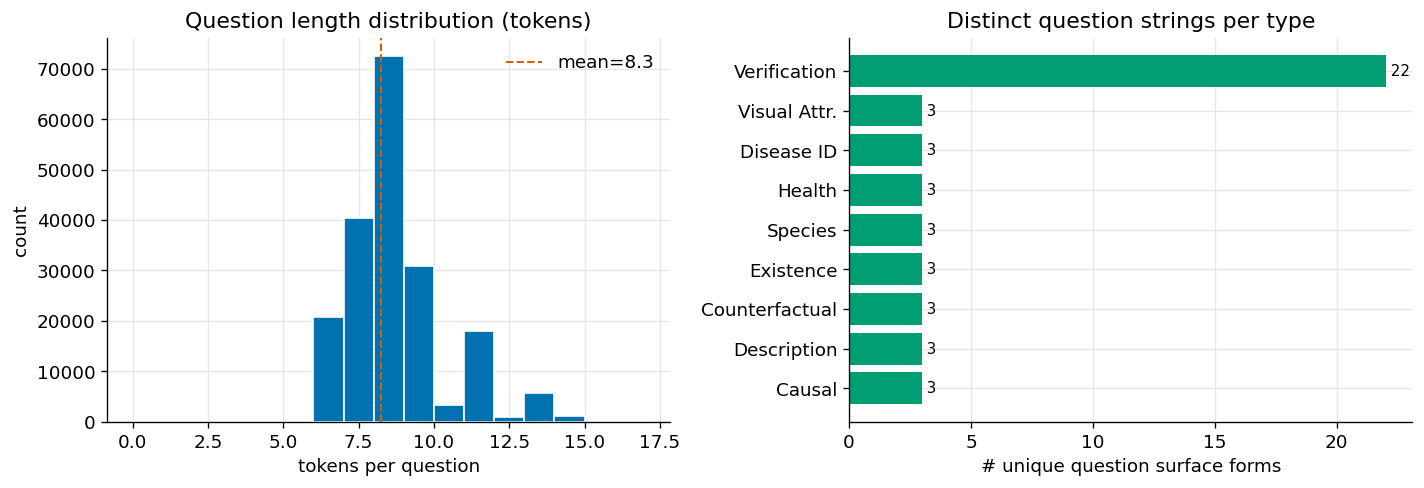

Saved: /kaggle/working/review_revision/figures/dataset_diversity.png


In [32]:
# ============================================================
# §8.4 Figures: question-length distribution + per-type unique templates
# ============================================================
if DIVERSITY_AVAILABLE and len(lengths) and len(templates_per_type):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    bins = range(0, int(lengths.max()) + 2)
    axes[0].hist(lengths, bins=bins, color=PALETTE[0], edgecolor="white")
    axes[0].set_title("Question length distribution (tokens)")
    axes[0].set_xlabel("tokens per question")
    axes[0].set_ylabel("count")
    axes[0].axvline(lengths.mean(), color=PALETTE[3], ls="--", lw=1.2,
                    label=f"mean={lengths.mean():.1f}")
    axes[0].legend(frameon=False)

    tp = templates_per_type.sort_values()
    short_names = [QTYPE_SHORT.get(k, k) for k in tp.index]
    axes[1].barh(short_names, tp.values, color=PALETTE[2])
    axes[1].set_title("Distinct question strings per type")
    axes[1].set_xlabel("# unique question surface forms")
    for y, v in enumerate(tp.values):
        axes[1].text(v, y, f" {v}", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig(REV_FIG / "dataset_diversity.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", REV_FIG / "dataset_diversity.png")

### §8.5 — Interpretation (drafted for the paper)

**Linguistic diversity (R1.5).** The metrics above characterise the generated questions precisely:
a low type-token ratio and low distinct-1/2/3, a small number of unique surface forms per question
type (templates by construction), and a narrow length distribution. This is the expected fingerprint
of deterministic template generation. It is a deliberate design choice — it guarantees clean,
unambiguous supervision and reproducibility — but it means the questions **do not** span the
morphological and syntactic variety of natural Bengali user queries (honorifics, dialectal spellings,
code-mixing, free word order). We state this as an explicit limitation and frame paraphrase
augmentation / LLM-based question rewriting + a small human-authored query set as future work.

**Vocabulary of 132 tokens (R2.1, Section 3.2).** The 132-token vocabulary is a *consequence* of the
above, not character-level tokenization: a **word-level** tokenizer fit on templated questions yields
a small **closed** vocabulary that covers ~100% of the question tokens it will ever see. Answers are
handled as a **separate closed classification space** (the answer head), not generated token-by-token,
so the small question vocabulary does not bottleneck answer expressivity within this benchmark. The
correct caveat — which we add to Section 3.2 — is that this tokenizer is scoped to the templated
benchmark and would need a subword/BPE tokenizer (and more diverse training text) before deployment
on open-ended Bengali input.

---
# §9 — Consolidated results, paper-ready text & response to reviewers

This section (1) collects every artifact produced above into one summary, and (2) provides
**drafted paragraphs** you can paste into the paper / rebuttal for each reviewer comment. The
experiment-backed paragraphs (R1.4, R1.5, R2.2, R2.3, R1.2, R1.3) reference the tables/figures saved
under `review_revision/reports/` and `review_revision/figures/`.

In [33]:
# ============================================================
# §9.1 Consolidated machine-readable summary and evidence notes
# ============================================================
def _read_csv_records(path):
    path = Path(path)
    if not path.is_file():
        return None
    frame = pd.read_csv(path)
    # round-trip through JSON to remove NumPy scalar/NaN values
    return json.loads(frame.to_json(orient="records"))


def _read_json_file(path):
    path = Path(path)
    if not path.is_file():
        return None
    with open(path, encoding="utf-8") as handle:
        return json.load(handle)


def _read_text_file(path):
    path = Path(path)
    return path.read_text(encoding="utf-8") if path.is_file() else None


try:
    import torchvision as _torchvision_for_report
    _torchvision_version = str(_torchvision_for_report.__version__)
except Exception:
    _torchvision_version = None


summary = {
    "input_notebook_root": str(INPUT_NOTEBOOK_ROOT),
    "project_dir": str(PROJECT_DIR),
    "environment": {
        "python": sys.version.split()[0],
        "torch": str(torch.__version__),
        "torchvision": _torchvision_version,
        "device": str(DEVICE),
        "gpu_count": int(NUM_GPUS),
        "gpu_names": list(GPU_NAMES),
        "cuda_report": CUDA_REPORT,
        "channels_last_enabled": bool(USE_CHANNELS_LAST),
    },
    "data_integrity": {
        "rows": {
            "train": int(len(train_df)),
            "val": int(len(val_df)),
            "test": int(len(test_df)),
        },
        "image_path_status": IMAGE_PATH_STATUS,
        "image_level_split_overlap": SPLIT_OVERLAP_AUDIT,
        "label_space": {
            "answers": int(num_answers),
            "crops": int(num_crops),
            "diseases": int(num_diseases),
            "classes": int(num_classes),
            "tokenizer_slots": int(VOCAB_SIZE),
        },
    },
    "reported_portion3_reference": {
        "val_acc": 0.8078,
        "val_macro_f1": 0.8345,
        "test_acc": 0.8072,
        "test_macro_f1": 0.8341,
        "provenance": "existing Portion-3 exported result; not retrained in §4",
    },
    "per_category": _read_csv_records(
        REV_REP / "per_category_accuracy.csv"
    ),
    "species_health_error_diagnostics": _read_json_file(
        REV_REP / "species_health_error_diagnostics.json"
    ),
    "ablation": _read_csv_records(
        REV_REP / "ablation_results.csv"
    ),
    "ablation_claim_guardrail": _read_csv_records(
        REV_REP / "ablation_claim_guardrail.csv"
    ),
    "ablation_failures": _read_csv_records(
        REV_REP / "ablation_failures.csv"
    ),
    "loss_weight_sweep": _read_csv_records(
        REV_REP / "loss_weight_sweep.csv"
    ),
    "loss_weight_interpretation": _read_json_file(
        REV_REP / "loss_weight_interpretation.json"
    ),
    "loss_weight_paper_sentence": _read_text_file(
        REV_REP / "loss_weight_paper_sentence.txt"
    ),
    "loss_weight_sweep_failures": _read_csv_records(
        REV_REP / "loss_weight_sweep_failures.csv"
    ),
    "baseline_comparison": _read_csv_records(
        REV_REP / "baseline_comparison.csv"
    ),
    "clip": _read_json_file(
        REV_REP / "clip_baseline_status.json"
    ),
    "in_the_wild": _read_json_file(
        REV_REP / "in_the_wild_summary.json"
    ),
    "in_the_wild_status": _read_json_file(
        REV_REP / "in_the_wild_status.json"
    ),
    "dataset_diversity": _read_json_file(
        REV_REP / "dataset_diversity.json"
    ),
    "run_config": {
        "variant_epochs": int(VARIANT_EPOCHS),
        "sweep_epochs": int(SWEEP_EPOCHS),
        "subset_frac": float(SUBSET_FRAC),
        "seed": int(VARIANT_SEED),
        "quick_smoke": bool(QUICK_SMOKE),
        "require_clip": bool(REQUIRE_CLIP_BASELINE),
        "require_external": bool(REQUIRE_EXTERNAL_EVAL),
    },
}

with open(
    REV_REP / "revision_summary.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        summary,
        handle,
        indent=2,
        ensure_ascii=False,
        allow_nan=False,
    )

# Human-readable evidence notes. These report only what was actually generated.
evidence_lines = [
    "# TinyAgriVQA-BN Revision Evidence Notes",
    "",
    f"- Project directory: `{PROJECT_DIR}`",
    f"- Runtime: torch {torch.__version__}; GPUs: {GPU_NAMES or ['CPU']}",
    f"- Image-level split overlap: {SPLIT_OVERLAP_AUDIT}",
    "",
    "## Core analyses",
]
for label, path in [
    ("Per-category analysis", REV_REP / "per_category_accuracy.csv"),
    ("Ablation", REV_REP / "ablation_results.csv"),
    ("Loss-weight sensitivity", REV_REP / "loss_weight_sweep.csv"),
    ("Baseline table", REV_REP / "baseline_comparison.csv"),
    ("Dataset diversity", REV_REP / "dataset_diversity.json"),
]:
    evidence_lines.append(
        f"- {label}: {'completed' if Path(path).is_file() else 'not produced'}"
    )

evidence_lines += [
    "",
    "## Additional-input analyses",
    f"- Frozen CLIP visual-backbone comparator: {CLIP_STATUS}",
    f"- External field auxiliary-head transfer: {INTHEWILD_STATUS}",
    "",
    "## Claim guardrails",
    "- Treat the frozen CLIP experiment as a visual-backbone comparator, not full CLIP VQA.",
    "- Treat the external field experiment as auxiliary-head transfer, not open-ended VQA accuracy.",
    "- Use `ablation_claim_guardrail.csv` before describing any component as beneficial.",
    "- Use `loss_weight_paper_sentence.txt`; do not assume alpha=1 is optimal.",
]
(REV_REP / "evidence_notes.md").write_text(
    "\n".join(evidence_lines) + "\n",
    encoding="utf-8",
)

print(
    "Saved consolidated summary:",
    REV_REP / "revision_summary.json",
)
print("Saved evidence notes:", REV_REP / "evidence_notes.md")


Saved consolidated summary: /kaggle/working/review_revision/reports/revision_summary.json
Saved evidence notes: /kaggle/working/review_revision/reports/evidence_notes.md


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [34]:
# ============================================================
# §9.2 Evidence-aware response-to-reviewers checklist
# ============================================================
def _exists(path):
    return Path(path).is_file()


def _status_row(
    ref,
    reviewer_point,
    addressed_in,
    evidence_type,
    status,
    claim_ready,
    note,
):
    return {
        "ref": ref,
        "reviewer_point": reviewer_point,
        "addressed_in": addressed_in,
        "type": evidence_type,
        "status": status,
        "claim_ready": bool(claim_ready),
        "note": note,
    }


clip_completed = CLIP_STATUS == "completed"
external_completed = INTHEWILD_STATUS == "completed"
ablation_completed = (
    _exists(REV_REP / "ablation_results.csv")
    and _exists(REV_REP / "ablation_claim_guardrail.csv")
    and _exists(REV_FIG / "ablation.png")
)
loss_sweep_completed = (
    _exists(REV_REP / "loss_weight_sweep.csv")
    and _exists(REV_REP / "loss_weight_interpretation.json")
    and _exists(REV_REP / "loss_weight_paper_sentence.txt")
    and _exists(REV_FIG / "loss_weight_sweep.png")
)
per_category_completed = (
    _exists(REV_REP / "per_category_accuracy.csv")
    and _exists(REV_REP / "species_health_error_diagnostics.json")
    and _exists(REV_FIG / "per_category_accuracy.png")
)
diversity_completed = (
    _exists(REV_REP / "dataset_diversity.json")
    and _exists(REV_FIG / "dataset_diversity.png")
)
baseline_table_completed = _exists(
    REV_REP / "baseline_comparison.csv"
)

checklist_rows = [
    _status_row(
        "R1.1",
        "Novelty clarified",
        "§9.3 paper-use text",
        "writing",
        "addressed",
        True,
        "Contribution categories are separated without claiming unmeasured superiority.",
    ),
    _status_row(
        "R1.2",
        "In-the-wild validation",
        "§7 + in_the_wild_status.json",
        "experiment",
        "addressed" if external_completed else "pending optional external dataset",
        external_completed,
        (
            "Auxiliary-head field transfer completed."
            if external_completed
            else f"No field result is claimed; status: {INTHEWILD_STATUS}"
        ),
    ),
    _status_row(
        "R1.3",
        "Stronger pretrained visual-language comparison",
        "§6 + baseline_comparison.csv + clip_baseline_status.json",
        "experiment",
        (
            "addressed"
            if clip_completed
            else "partial: baseline table completed; CLIP comparator pending"
        ),
        clip_completed,
        (
            "Frozen CLIP visual-backbone comparator completed."
            if clip_completed
            else f"CLIP result is not claimed; status: {CLIP_STATUS}"
        ),
    ),
    _status_row(
        "R1.4",
        "Component ablation",
        "§4 + ablation_results.csv + claim guardrail",
        "experiment",
        "addressed" if ablation_completed else "not produced",
        ablation_completed,
        (
            "Use the generated guardrail; single-seed evidence is explicitly qualified."
            if ablation_completed
            else "Required core ablation artifacts are missing."
        ),
    ),
    _status_row(
        "R1.5",
        "Linguistic diversity and template limitation",
        "§8 + dataset_diversity.json",
        "experiment",
        "addressed" if diversity_completed else "not produced",
        diversity_completed,
        (
            "Diversity metrics and figure completed."
            if diversity_completed
            else "Diversity artifacts are missing."
        ),
    ),
    _status_row(
        "R2.1",
        "132-token vocabulary clarified",
        "§8.3 + §9.3 text",
        "experiment + writing",
        "addressed" if diversity_completed else "partial",
        diversity_completed,
        "The vocabulary is scoped to the closed templated benchmark.",
    ),
    _status_row(
        "R2.2",
        "Loss-weight justification",
        "§5 + data-dependent paper sentence",
        "experiment + writing",
        "addressed" if loss_sweep_completed else "not produced",
        loss_sweep_completed,
        (
            "The generated sentence reports the observed best scale without assuming alpha=1 is optimal."
            if loss_sweep_completed
            else "Required core sensitivity artifacts are missing."
        ),
    ),
    _status_row(
        "R2.3",
        "Species and Health error explanation",
        "§3 + error-family diagnostics",
        "experiment",
        "addressed" if per_category_completed else "not produced",
        per_category_completed,
        (
            "Interpretation distinguishes answer-family leakage from visual ambiguity."
            if per_category_completed
            else "Per-category diagnostic artifacts are missing."
        ),
    ),
]

chk = pd.DataFrame(checklist_rows)
chk.to_csv(
    REV_REP / "response_to_reviewers.csv",
    index=False,
)

markdown_lines = [
    "# Response-to-Reviewers Evidence Status",
    "",
    "| Ref | Point | Status | Claim ready | Note |",
    "|---|---|---|:---:|---|",
]
for row in checklist_rows:
    markdown_lines.append(
        "| {ref} | {point} | {status} | {ready} | {note} |".format(
            ref=row["ref"],
            point=row["reviewer_point"].replace("|", "/"),
            status=row["status"].replace("|", "/"),
            ready="yes" if row["claim_ready"] else "no",
            note=row["note"].replace("|", "/"),
        )
    )
(REV_REP / "response_to_reviewers.md").write_text(
    "\n".join(markdown_lines) + "\n",
    encoding="utf-8",
)

print(
    chk[
        ["ref", "reviewer_point", "status", "claim_ready"]
    ].to_string(index=False)
)


 ref                                 reviewer_point                                                     status  claim_ready
R1.1                              Novelty clarified                                                  addressed         True
R1.2                         In-the-wild validation                          pending optional external dataset        False
R1.3 Stronger pretrained visual-language comparison partial: baseline table completed; CLIP comparator pending        False
R1.4                             Component ablation                                                  addressed         True
R1.5   Linguistic diversity and template limitation                                                  addressed         True
R2.1                 132-token vocabulary clarified                                                  addressed         True
R2.2                      Loss-weight justification                                                  addressed         True
R2.3    

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### §9.3 — Paper-use text and evidence rules

**R1.1 — Contribution scope.**  
The contribution has three separable parts: *(i)* a controlled Bengali crop-disease VQA benchmark
derived from PlantVillage with nine question types and reliability-masked auxiliary labels; *(ii)* a
compact image–text architecture with a ResNet image tower, lightweight Bengali Transformer, gated
fusion, and auxiliary heads; and *(iii)* masked multitask training. The manuscript should report the
measured removal deltas from `ablation_results.csv` and follow
`ablation_claim_guardrail.csv`. It should not state that every component is independently beneficial
when a validation/test effect is mixed.

**R2.1 — Tokenization clarification.**  
The question tokenizer is word-level and fitted to the deterministic template corpus. The resulting
132-token closed vocabulary covers the benchmark question distribution, while answers are represented
by a separate closed classification head. This does not make the system suitable for unrestricted
Bengali queries. Open-ended use would require diverse human-authored text and a subword tokenizer.

**R2.2 — Loss weights.**  
Use the exact sentence written to `reports/loss_weight_paper_sentence.txt`. It is generated from the
observed sweep and therefore reports the best tested scale honestly. Do not replace it with a
prewritten claim that `alpha=1` is optimal.

**R2.3 — Species and Health errors.**  
The per-category analysis should distinguish visual ambiguity from answer-family incompatibility.
For Species questions, a meaningful share of errors may be yes/no or other answer-family outputs
rather than another crop name. Health errors can be summarized as binary label reversals. Use
`species_health_error_diagnostics.json` for the measured proportions instead of attributing all
errors to similar leaf appearance.

**R1.3 — Pretrained comparator.**  
The optional CLIP experiment replaces the visual tower with a frozen CLIP vision encoder while
retaining the Bengali text encoder and classifier. Report it as a **pretrained visual-backbone
comparator**, not a full CLIP-based VQA system. When no local CLIP weights are attached, its status is
pending and no score should be claimed.

**R1.2 — Field-domain evaluation.**  
The optional external experiment reports zero-shot crop/health auxiliary-head transfer on a separate
field dataset. It is not open-ended VQA accuracy. When no external dataset is attached, report the
evaluation as pending rather than implying that field validation was completed.

**Camera-ready protocol.**  
`QUICK_SMOKE=True` is only a structural test. For manuscript numbers, use full data, an appropriate
epoch budget, and preferably multiple seeds. Keep the generated status, guardrail, and provenance
files with every table copied into the paper.


In [35]:
# ============================================================
# §10 Verification, readiness gates, and output package
# ============================================================
import zipfile


core_expected = [
    ("§3 per-category table", REV_REP / "per_category_accuracy.csv", RUN_PER_CATEGORY),
    ("§3 per-category figure", REV_FIG / "per_category_accuracy.png", RUN_PER_CATEGORY),
    (
        "§3 Species/Health diagnostics",
        REV_REP / "species_health_error_diagnostics.json",
        RUN_PER_CATEGORY,
    ),
    ("§4 ablation table", REV_REP / "ablation_results.csv", RUN_ABLATIONS),
    (
        "§4 ablation claim guardrail",
        REV_REP / "ablation_claim_guardrail.csv",
        RUN_ABLATIONS,
    ),
    ("§4 ablation figure", REV_FIG / "ablation.png", RUN_ABLATIONS),
    ("§5 loss sweep table", REV_REP / "loss_weight_sweep.csv", RUN_LOSS_SWEEP),
    (
        "§5 loss interpretation",
        REV_REP / "loss_weight_interpretation.json",
        RUN_LOSS_SWEEP,
    ),
    (
        "§5 paper sentence",
        REV_REP / "loss_weight_paper_sentence.txt",
        RUN_LOSS_SWEEP,
    ),
    ("§5 loss sweep figure", REV_FIG / "loss_weight_sweep.png", RUN_LOSS_SWEEP),
    (
        "§6 baseline table",
        REV_REP / "baseline_comparison.csv",
        RUN_BASELINES,
    ),
    (
        "§6 CLIP status",
        REV_REP / "clip_baseline_status.json",
        RUN_BASELINES and RUN_CLIP_BASELINE,
    ),
    (
        "§7 external status",
        REV_REP / "in_the_wild_status.json",
        RUN_INTHEWILD,
    ),
    (
        "§8 diversity report",
        REV_REP / "dataset_diversity.json",
        RUN_DIVERSITY,
    ),
    (
        "§8 diversity figure",
        REV_FIG / "dataset_diversity.png",
        RUN_DIVERSITY,
    ),
    (
        "§9 consolidated summary",
        REV_REP / "revision_summary.json",
        True,
    ),
    (
        "§9 evidence notes",
        REV_REP / "evidence_notes.md",
        True,
    ),
    (
        "§9 response checklist CSV",
        REV_REP / "response_to_reviewers.csv",
        True,
    ),
    (
        "§9 response checklist Markdown",
        REV_REP / "response_to_reviewers.md",
        True,
    ),
]

optional_result_expected = [
    (
        "R1.3 completed CLIP comparator",
        REV_REP / "clip_baseline_status.json",
        bool(REQUIRE_CLIP_BASELINE),
        CLIP_STATUS == "completed",
        CLIP_STATUS,
    ),
    (
        "R1.2 completed field transfer",
        REV_REP / "in_the_wild_summary.json",
        bool(REQUIRE_EXTERNAL_EVAL),
        INTHEWILD_STATUS == "completed",
        INTHEWILD_STATUS,
    ),
]

inventory_rows = []
missing_core = []

print("=" * 88)
print("ARTIFACT VERIFICATION")
print("=" * 88)

for name, path, requested in core_expected:
    path = Path(path)
    exists = path.is_file()
    if not requested:
        status = "NOT REQUESTED"
    elif exists:
        status = "OK"
    else:
        status = "MISSING CORE"
        missing_core.append(name)
    inventory_rows.append({
        "category": "core/status",
        "artifact": name,
        "requested": bool(requested),
        "required": bool(requested),
        "exists": bool(exists),
        "status": status,
        "path": str(path),
    })
    print(f"  {status:16s} {name:32s} -> {path}")

optional_requirement_failures = []
for name, path, required, completed, detail in optional_result_expected:
    path = Path(path)
    if completed:
        status = "COMPLETED"
    elif required:
        status = "REQUIRED BUT INCOMPLETE"
        optional_requirement_failures.append(f"{name}: {detail}")
    else:
        status = "PENDING OPTIONAL INPUT"
    inventory_rows.append({
        "category": "additional-input result",
        "artifact": name,
        "requested": True,
        "required": bool(required),
        "exists": bool(path.is_file()),
        "status": status,
        "path": str(path),
        "detail": str(detail),
    })
    print(f"  {status:24s} {name:32s} -> {detail}")

inventory = pd.DataFrame(inventory_rows)
inventory.to_csv(
    REV_REP / "artifact_inventory.csv",
    index=False,
)

all_reviewer_points_ready = bool(
    len(chk) and chk["claim_ready"].astype(bool).all()
)
core_execution_complete = not missing_core
required_additional_complete = not optional_requirement_failures

readiness = {
    "core_execution_complete": core_execution_complete,
    "required_additional_inputs_complete": required_additional_complete,
    "all_reviewer_points_claim_ready": all_reviewer_points_ready,
    "missing_core_artifacts": missing_core,
    "required_additional_failures": optional_requirement_failures,
    "clip_status": CLIP_STATUS,
    "in_the_wild_status": INTHEWILD_STATUS,
    "quick_smoke": bool(QUICK_SMOKE),
    "camera_ready_numbers": bool(
        core_execution_complete
        and not QUICK_SMOKE
        and SUBSET_FRAC >= 1.0
        and VARIANT_EPOCHS >= 12
        and SWEEP_EPOCHS >= 6
    ),
    "interpretation": (
        "Core notebook execution succeeded. Reviewer coverage may remain partial "
        "when optional CLIP weights or a separate field dataset were not attached."
        if core_execution_complete
        else "Core notebook execution is incomplete."
    ),
}
with open(
    REV_REP / "revision_readiness.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        readiness,
        handle,
        indent=2,
        ensure_ascii=False,
        allow_nan=False,
    )

# Add the final readiness block to the consolidated summary.
summary_path = REV_REP / "revision_summary.json"
if summary_path.is_file():
    with open(summary_path, encoding="utf-8") as handle:
        final_summary = json.load(handle)
    final_summary["readiness"] = readiness
    with open(summary_path, "w", encoding="utf-8") as handle:
        json.dump(
            final_summary,
            handle,
            indent=2,
            ensure_ascii=False,
            allow_nan=False,
        )

# Package reports, figures, and histories. Transient model-state cache is excluded.
archive_path = (
    Path("/kaggle/working/review_revision_artifacts.zip")
    if Path("/kaggle/working").exists()
    else Path("./review_revision_artifacts.zip")
)
if archive_path.exists():
    archive_path.unlink()

with zipfile.ZipFile(
    archive_path,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6,
) as archive:
    for file_path in sorted(REV_DIR.rglob("*")):
        if not file_path.is_file():
            continue
        relative = file_path.relative_to(REV_DIR)
        if relative.parts and relative.parts[0] == "cache":
            continue
        archive.write(file_path, arcname=str(relative))

if not KEEP_VARIANT_CHECKPOINTS:
    shutil.rmtree(REV_CACHE, ignore_errors=True)

print("\nReadiness:")
print(json.dumps(readiness, indent=2, ensure_ascii=False))
print("\nPackaged outputs:", archive_path)

# Core experiments are strict; additional-input experiments are strict only
# when the corresponding REQUIRE_* flag is enabled.
if STRICT_CORE_VALIDATION and missing_core:
    raise RuntimeError(
        "Core reviewer evidence was not produced: "
        + ", ".join(missing_core)
    )
if optional_requirement_failures:
    raise RuntimeError(
        "Required additional-input evidence is incomplete: "
        + "; ".join(optional_requirement_failures)
    )

print(
    "\nNotebook core completed without unhandled errors."
    if core_execution_complete
    else "\nNotebook core is incomplete."
)
if all_reviewer_points_ready:
    print("All reviewer points have claim-ready evidence.")
else:
    print(
        "Some reviewer points remain explicitly pending additional inputs; "
        "no unsupported result was claimed."
    )
print("Outputs:", REV_DIR)


ARTIFACT VERIFICATION
  OK               §3 per-category table            -> /kaggle/working/review_revision/reports/per_category_accuracy.csv
  OK               §3 per-category figure           -> /kaggle/working/review_revision/figures/per_category_accuracy.png
  OK               §3 Species/Health diagnostics    -> /kaggle/working/review_revision/reports/species_health_error_diagnostics.json
  OK               §4 ablation table                -> /kaggle/working/review_revision/reports/ablation_results.csv
  OK               §4 ablation claim guardrail      -> /kaggle/working/review_revision/reports/ablation_claim_guardrail.csv
  OK               §4 ablation figure               -> /kaggle/working/review_revision/figures/ablation.png
  OK               §5 loss sweep table              -> /kaggle/working/review_revision/reports/loss_weight_sweep.csv
  OK               §5 loss interpretation           -> /kaggle/working/review_revision/reports/loss_weight_interpretation.json
  OK       

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Readiness:
{
  "core_execution_complete": true,
  "required_additional_inputs_complete": true,
  "all_reviewer_points_claim_ready": false,
  "missing_core_artifacts": [],
  "required_additional_failures": [],
  "clip_status": "skipped: no local CLIP model found and network download is disabled",
  "in_the_wild_status": "skipped: no external field dataset found",
  "quick_smoke": false,
  "camera_ready_numbers": false,
  "interpretation": "Core notebook execution succeeded. Reviewer coverage may remain partial when optional CLIP weights or a separate field dataset were not attached."
}

Packaged outputs: /kaggle/working/review_revision_artifacts.zip

Notebook core completed without unhandled errors.
Some reviewer points remain explicitly pending additional inputs; no unsupported result was claimed.
Outputs: /kaggle/working/review_revision


---
## Appendix — reliable Kaggle execution

1. Add the saved Portion 1–3 notebook output. The first-choice path is
   `/kaggle/input/notebooks/nabidnur/iciset-2026`, with automatic support for the nested
   `tinyagrivqa_bn/` project folder.
2. Prefer **GPU T4 ×2**. The preflight verifies the GPU architecture before training. A P100 fallback
   can install a compatible PyTorch build only when Internet is enabled and
   `ALLOW_RUNTIME_TORCH_COMPAT_INSTALL=True`.
3. Run from a fresh session after changing PyTorch or GPU settings. The notebook launches a real CUDA
   operation before starting the multi-hour experiments.
4. The core analyses—prediction diagnostics, ablation, loss sensitivity, baseline table, and
   diversity—are strict. Missing core artifacts fail the final gate.
5. The frozen CLIP visual-backbone comparator requires a local Hugging Face model directory, or
   network download must be explicitly enabled. A missing CLIP model is recorded as pending unless
   `REQUIRE_CLIP_BASELINE=True`.
6. The field-domain section requires a separate ImageFolder-style dataset such as PlantDoc. Set
   `TINYAGRIVQA_EXTERNAL_DIR` or rely on safe discovery. The controlled Portion 1–3 data are excluded.
   A missing external dataset is recorded as pending unless `REQUIRE_EXTERNAL_EVAL=True`.
7. `QUICK_SMOKE=True` validates notebook structure only. Camera-ready evidence should use full data,
   a defensible epoch budget, and preferably multiple seeds.
8. Outputs are written to `/kaggle/working/review_revision/`; the final cell creates
   `/kaggle/working/review_revision_artifacts.zip`, excluding temporary checkpoint cache.
9. Read `revision_readiness.json`, `response_to_reviewers.csv`, and the claim-guardrail files before
   copying any result into the manuscript.
